# Análisis descriptivo de competencias EAL (2022–2024)

**Pregunta de negocio.** ¿Cómo podríamos ajustar nuestras políticas de formación para alinearlas con las tendencias formativas del sector —en competencias clave, medios utilizados y barreras más comunes— y aumentar el impacto del desarrollo profesional en nuestra organización?

Este notebook responde exclusivamente a la parte de **competencias** y concentra el análisis en **Servicios**, el mayor detalle sectorial comparable disponible y, por tanto, una aproximación amplia —no equivalente— a Transporte y almacenamiento.

**Inferencia estadística.** Se incorpora el contraste Z exploratorio. Para EAL-16 se utilizan las muestras de Servicios de 2022 (**6.266 empresas**), 2023 (**6.107**) y 2024 (**5.963**). Para EAL-21 se aproximan muestras formadoras de **4.366**, **4.314** y **4.302** empresas a partir de EAL-C1 y EAL-17/EAL-18a. Estas pruebas detectan señales compatibles con diferencias interanuales, pero no deben interpretarse como evidencia confirmatoria porque no incorporan el diseño muestral y realizan múltiples contrastes.

## Contexto y métodos

### Alcance

- Periodo: 2022, 2023 y 2024.
- Ámbito sectorial principal: **Servicios**, utilizado como aproximación amplia a Transporte y almacenamiento.
- Importancia futura: porcentaje `Bastante + Mucho` de EAL-16.
- Formación actual por sector: porcentaje de empresas formadoras que ofrece cada competencia en EAL-21.
- Unidad analítica: competencia × año × indicador.
- No se atribuyen a Transporte y almacenamiento resultados que solo están publicados para Servicios.

### Preguntas analíticas

1. ¿Cuáles son las competencias prioritarias en cada año?
2. ¿Qué competencias ganan o pierden relevancia entre años?
3. ¿La formación ofrecida evoluciona en la misma dirección?
4. ¿Qué diferencias tienen una magnitud relevante para negocio?
5. ¿Qué cambios muestran señales estadísticas exploratorias?

### Reglas de interpretación

- Cambio menor de 2 pp: **estable**.
- Cambio de 2 a menos de 5 pp: **moderado**.
- Cambio de 5 pp o más: **notable**.

Estos umbrales son reglas descriptivas para priorizar decisiones, no pruebas estadísticas. EAL-16 y EAL-21 tienen universos distintos; la alineación se analiza mediante rankings y percentiles, no mediante una resta de porcentajes brutos.

## Imports

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.lines import Line2D
from matplotlib.path import Path as MplPath
from matplotlib.patches import PathPatch
from matplotlib.ticker import PercentFormatter
from statsmodels.stats.proportion import proportions_ztest

## Configuración genérica

In [2]:
ANIOS = [2022, 2023, 2024]

pd.set_option("display.max_colwidth", 70)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

AZUL = "#0B4EA2"
AZUL_CLARO = "#3AAEF5"
NARANJA = "#D8842F"
GRIS = "#66747C"
GRIS_CLARO = "#DCE2E5"
TINTA = "#222222"

plt.rcParams.update({
    "figure.dpi": 110,
    "figure.facecolor": "#FFFFFF",
    "axes.facecolor": "#FFFFFF",
    "font.size": 10,
    "axes.titlesize": 18,
    "axes.titleweight": "bold",
    "axes.titlecolor": "#264653",
    "axes.labelcolor": "#222222",
    "xtick.color": "#222222",
    "ytick.color": "#222222",
    "axes.axisbelow": True,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.spines.left": False,
    "axes.spines.bottom": False,
    "xtick.major.size": 0,
    "ytick.major.size": 0,
})


# Sistema visual adaptado de "Distribución de niveles por perfil de comportamiento"
COLOR_BARRA_CONTEXTO = "#3AAEF5"
COLOR_BARRA_ENFASIS = "#0B4EA2"
COLOR_TEXTO_BARRAS = "#222222"
COLOR_TITULO_BARRAS = "#264653"
COLOR_GRID_BARRAS = "#D9D9D9"
COLOR_FONDO_BARRAS = "#FFFFFF"


def crear_barra_horizontal_derecha_redondeada(
    ax,
    y_centro,
    ancho,
    alto,
    color,
    radio_pixeles=14,
):
    """Dibuja una barra horizontal con el extremo derecho redondeado."""
    x0 = 0
    x1 = ancho
    y0 = y_centro - alto / 2
    y1 = y_centro + alto / 2

    origen_display = ax.transData.transform((0, 0))
    origen_data = ax.transData.inverted().transform(origen_display)
    punto_x = ax.transData.inverted().transform(
        origen_display + np.array([radio_pixeles, 0])
    )
    punto_y = ax.transData.inverted().transform(
        origen_display + np.array([0, radio_pixeles])
    )
    radio_x = min(abs(punto_x[0] - origen_data[0]), ancho)
    radio_y = min(abs(punto_y[1] - origen_data[1]), alto / 2)
    kappa = 0.5522847498

    vertices = [
        (x0, y0),
        (x1 - radio_x, y0),
        (x1 - radio_x + kappa * radio_x, y0),
        (x1, y0 + radio_y - kappa * radio_y),
        (x1, y0 + radio_y),
        (x1, y1 - radio_y),
        (x1, y1 - radio_y + kappa * radio_y),
        (x1 - radio_x + kappa * radio_x, y1),
        (x1 - radio_x, y1),
        (x0, y1),
        (x0, y0),
        (x0, y0),
    ]
    codigos = [
        MplPath.MOVETO,
        MplPath.LINETO,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.LINETO,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.CURVE4,
        MplPath.LINETO,
        MplPath.LINETO,
        MplPath.CLOSEPOLY,
    ]
    ax.add_patch(
        PathPatch(
            MplPath(vertices, codigos),
            facecolor=color,
            edgecolor="none",
            linewidth=0,
            zorder=3,
        )
    )


def crear_grafico_barras_horizontales_perfil(
    tabla,
    titulo,
    subtitulo,
    etiqueta_eje_x,
    limite_x,
    figsize,
):
    """Replica en horizontal el diseño del notebook de absentismo."""
    datos = tabla.reset_index(drop=True).copy()
    posiciones = np.arange(len(datos))
    alto_barra = 0.68

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor(COLOR_FONDO_BARRAS)
    ax.set_facecolor(COLOR_FONDO_BARRAS)

    ax.set_xlim(0, limite_x)
    ax.set_ylim(-0.65, len(datos) - 0.35)
    ax.set_yticks(posiciones)
    ax.set_yticklabels(
        datos["etiqueta"],
        fontsize=11,
        color=COLOR_TEXTO_BARRAS,
    )
    ax.invert_yaxis()

    ax.set_title(
        titulo,
        fontsize=18,
        fontweight="bold",
        color=COLOR_TITULO_BARRAS,
        loc="center",
        pad=46,
    )
    ax.text(
        0.5,
        1.015,
        subtitulo,
        transform=ax.transAxes,
        ha="center",
        va="bottom",
        fontsize=10.5,
        color=GRIS,
    )
    ax.set_xlabel(
        etiqueta_eje_x,
        fontsize=11,
        color=COLOR_TEXTO_BARRAS,
        labelpad=12,
    )
    ax.set_ylabel("")
    ax.xaxis.set_major_formatter(
        PercentFormatter(xmax=100, decimals=0)
    )
    ax.grid(
        axis="x",
        linestyle="-",
        linewidth=0.8,
        alpha=0.65,
        color=COLOR_GRID_BARRAS,
        zorder=0,
    )
    ax.grid(axis="y", visible=False)
    ax.set_axisbelow(True)

    for spine in ["top", "right", "left", "bottom"]:
        ax.spines[spine].set_visible(False)
    ax.tick_params(
        axis="x",
        length=0,
        colors=COLOR_TEXTO_BARRAS,
        labelsize=10,
    )
    ax.tick_params(axis="y", length=0, colors=COLOR_TEXTO_BARRAS)

    for tick, es_top_3 in zip(
        ax.get_yticklabels(),
        datos["es_top_3"],
    ):
        if es_top_3:
            tick.set_fontweight("bold")

    plt.tight_layout()
    fig.canvas.draw()

    for posicion, (_, fila) in zip(posiciones, datos.iterrows()):
        color = (
            COLOR_BARRA_ENFASIS
            if fila["es_top_3"]
            else COLOR_BARRA_CONTEXTO
        )
        crear_barra_horizontal_derecha_redondeada(
            ax=ax,
            y_centro=posicion,
            ancho=fila["valor"],
            alto=alto_barra,
            color=color,
            radio_pixeles=14,
        )
        ax.text(
            fila["valor"] + limite_x * 0.012,
            posicion,
            f'{fila["valor"]:.1f}%',
            ha="left",
            va="center",
            fontsize=10,
            fontweight="bold" if fila["es_top_3"] else "normal",
            color=COLOR_TEXTO_BARRAS,
            zorder=4,
        )

    plt.show()

directorio_actual = Path.cwd().resolve()
candidatos_raiz = [directorio_actual, *directorio_actual.parents]
ROOT = next(
    (
        candidato
        for candidato in candidatos_raiz
        if (candidato / "Data" / "Encuesta_EAL").is_dir()
    ),
    None,
)
if ROOT is None:
    raise FileNotFoundError(
        "No se encontró la raíz del proyecto con Data/Encuesta_EAL "
        f"desde {directorio_actual}"
    )

DATA_FILE = ROOT / "Data" / "Encuesta_EAL" / "processed" / "Tablas_EAL_Competencies_2022-2024.csv"
TABLAS_DIR = ROOT / "Data" / "Encuesta_EAL" / "Raw_2022-2024"
    
ETIQUETAS = {
    "administrativas_oficina": "Administrativas",
    "atencion_clientes": "Atención al cliente",
    "basicas_calculo_comunicacion": "Básicas",
    "direccion": "Dirección",
    "lenguas_extranjeras": "Lenguas extranjeras",
    "otras": "Otras",
    "resolucion_problemas": "Resolución de problemas",
    "tecnicas_puesto": "Técnicas del puesto",
    "tic_generales": "TIC generales",
    "tic_profesionales": "TIC profesionales",
    "trabajo_equipo": "Trabajo en equipo",
}

ACTIVIDADES_SERVICIOS = [
    "Comercio y reparación de vehículos",
    "Transporte y almacenamiento",
    "Hostelería",
    "Información, comunicaciones, actividades financieras, de seguros e inmobiliarias",
    "Actividades profesionales, científicas y técnicas",
    "Actividades administrativas y servicios auxiliares",
    "Actividades artísticas, recreativas y de entretenimiento y otros servicios",
]

N_MUESTRA_SERVICIOS = {2022: 6266, 2023: 6107, 2024: 5963}
FUENTES_FORMADORAS = {
    2022: {"hoja": "EAL-17", "columna_porcentaje": 2},
    2023: {"hoja": "EAL-18a", "columna_porcentaje": 1},
    2024: {"hoja": "EAL-18a", "columna_porcentaje": 1},
}

## Carga de datos

In [3]:
datos = pd.read_csv(DATA_FILE)

tablas_c1 = {}
tablas_formadoras = {}
for anio in ANIOS:
    archivo_anual = TABLAS_DIR / f"Tablas_EAL_{anio}.xlsx"
    tablas_c1[anio] = pd.read_excel(archivo_anual, sheet_name="EAL-C1", header=None)
    tablas_formadoras[anio] = pd.read_excel(
        archivo_anual,
        sheet_name=FUENTES_FORMADORAS[anio]["hoja"],
        header=None,
    )

print(f"Fuente: {DATA_FILE}")
print(f"Dimensión: {datos.shape[0]:,} filas × {datos.shape[1]} columnas")
print(f"Tablas anuales cargadas: {ANIOS}")

Fuente: C:\Users\raulm\Desktop\Simulator\ProjecteData\Equip_33\Data\Encuesta_EAL\processed\Tablas_EAL_Competencies_2022-2024.csv
Dimensión: 1,170 filas × 12 columnas
Tablas anuales cargadas: [2022, 2023, 2024]


## Resultados

### 1. Preparación de los indicadores

In [4]:
# Importancia futura: Bastante + Mucho, Servicios
importancia = (
    datos.query(
        "tema == 'importancia_futura' and desglose == 'sector' and "
        "corte == 'Servicios' and indicador in ['bastante', 'mucho']"
    )
    .groupby(["anio", "competencia_id", "competencia"], as_index=False)["porcentaje"]
    .sum()
    .rename(columns={"porcentaje": "valor"})
)
importancia["indicador"] = "Importancia futura"

# Formación ofrecida: Servicios
formacion = (
    datos.query(
        "tema == 'formacion_ofrecida' and desglose == 'sector' and corte == 'Servicios'"
    )[["anio", "competencia_id", "competencia", "porcentaje"]]
    .rename(columns={"porcentaje": "valor"})
)
formacion["indicador"] = "Formación ofrecida"

for tabla in [importancia, formacion]:
    tabla["rank"] = tabla.groupby("anio")["valor"].rank(ascending=False, method="min").astype(int)
    tabla["etiqueta"] = tabla["competencia_id"].map(ETIQUETAS)

def preparar_evolucion(tabla, nombre_indicador):
    valores = tabla.pivot(index=["competencia_id", "competencia", "etiqueta"], columns="anio", values="valor").reset_index()
    rangos = tabla.pivot(index="competencia_id", columns="anio", values="rank").add_prefix("rank_").reset_index()
    salida = valores.merge(rangos, on="competencia_id", validate="one_to_one")
    salida["cambio_22_23_pp"] = salida[2023] - salida[2022]
    salida["cambio_23_24_pp"] = salida[2024] - salida[2023]
    salida["cambio_22_24_pp"] = salida[2024] - salida[2022]
    salida["indicador"] = nombre_indicador
    return salida

def clasificar_magnitud(cambio_pp):
    if abs(cambio_pp) >= 5:
        return "Notable (≥5 pp)"
    if abs(cambio_pp) >= 2:
        return "Moderado (2–<5 pp)"
    return "Estable (<2 pp)"

evol_importancia = preparar_evolucion(importancia, "Importancia futura")
evol_formacion = preparar_evolucion(formacion, "Formación ofrecida")
for tabla in [evol_importancia, evol_formacion]:
    tabla["magnitud_22_24"] = tabla["cambio_22_24_pp"].map(clasificar_magnitud)

#### Estimación de muestras y contrastes exploratorios

Se estima el denominador de empresas formadoras y se calculan las señales
exploratorias utilizadas posteriormente en los gráficos.

In [5]:
def valor_por_etiqueta(tabla, etiqueta, columna):
    coincidencias = tabla.loc[
        tabla.iloc[:, 0].astype(str).str.strip().eq(etiqueta),
        tabla.columns[columna],
    ]
    if len(coincidencias) != 1:
        raise ValueError(f"Se esperaba una fila para {etiqueta!r}; encontradas: {len(coincidencias)}")
    return float(coincidencias.iloc[0])

def estimar_formadoras():
    filas = []
    for anio in ANIOS:
        empresas_servicios = 0.0
        empresas_formadoras = 0.0
        fuente = FUENTES_FORMADORAS[anio]
        for actividad in ACTIVIDADES_SERVICIOS:
            empresas_actividad = valor_por_etiqueta(tablas_c1[anio], actividad, 1)
            tasa_formadoras = valor_por_etiqueta(
                tablas_formadoras[anio],
                actividad,
                fuente["columna_porcentaje"],
            )
            empresas_servicios += empresas_actividad
            empresas_formadoras += empresas_actividad * tasa_formadoras / 100

        tasa_formadoras_servicios = empresas_formadoras / empresas_servicios
        filas.append({
            "anio": anio,
            "fuente_porcentaje": fuente["hoja"],
            "empresas_servicios_marco": round(empresas_servicios),
            "empresas_formadoras_estimadas": round(empresas_formadoras),
            "porcentaje_formadoras_servicios": tasa_formadoras_servicios * 100,
            "muestra_servicios": N_MUESTRA_SERVICIOS[anio],
            "muestra_formadoras_aproximada": round(
                N_MUESTRA_SERVICIOS[anio] * tasa_formadoras_servicios
            ),
        })
    return pd.DataFrame(filas)

def test_diferencia_proporciones(porcentaje_inicial, n_inicial, porcentaje_final, n_final):
    conteos = [
        round(porcentaje_inicial * n_inicial / 100),
        round(porcentaje_final * n_final / 100),
    ]
    _, p_valor = proportions_ztest(conteos, [n_inicial, n_final])
    return float(p_valor)

def calcular_significacion(tabla, nombre_indicador, muestras, calidad_inferencia):
    valores = tabla.pivot(
        index=["competencia_id", "competencia", "etiqueta"],
        columns="anio",
        values="valor",
    )
    resultados = []
    for (competencia_id, competencia, etiqueta), fila in valores.iterrows():
        for anio_inicial, anio_final in zip(ANIOS[:-1], ANIOS[1:]):
            porcentaje_inicial = fila.get(anio_inicial)
            porcentaje_final = fila.get(anio_final)
            if pd.isna(porcentaje_inicial) or pd.isna(porcentaje_final):
                continue
            p_valor = test_diferencia_proporciones(
                porcentaje_inicial,
                muestras[anio_inicial],
                porcentaje_final,
                muestras[anio_final],
            )
            resultados.append({
                "indicador": nombre_indicador,
                "competencia_id": competencia_id,
                "competencia": competencia,
                "etiqueta": etiqueta,
                "periodo": f"{anio_inicial}→{anio_final}",
                "%_inicio": porcentaje_inicial,
                "%_fin": porcentaje_final,
                "variacion_pp": porcentaje_final - porcentaje_inicial,
                "p_valor": p_valor,
                "cambio_significativo": p_valor < 0.05,
                "calidad_inferencia": calidad_inferencia,
            })
    return pd.DataFrame(resultados)

estimacion_formadoras = estimar_formadoras()
N_MUESTRA_FORMADORAS_APROX = dict(zip(
    estimacion_formadoras["anio"],
    estimacion_formadoras["muestra_formadoras_aproximada"],
))

df_significacion = pd.concat([
    calcular_significacion(
        importancia,
        "Importancia futura",
        N_MUESTRA_SERVICIOS,
        "Test Z exploratorio con n sectorial",
    ),
    calcular_significacion(
        formacion,
        "Formación ofrecida",
        N_MUESTRA_FORMADORAS_APROX,
        "Test Z exploratorio con n formadoras aproximada",
    ),
], ignore_index=True).sort_values(["indicador", "periodo", "p_valor"]).reset_index(drop=True)
df_significacion["Señal exploratoria (p<0,05)"] = np.where(
    df_significacion["cambio_significativo"], "Sí", "No"
)


def diccionario_significacion(indicador):
    """Devuelve la señal exploratoria por competencia y periodo."""
    return (
        df_significacion.query("indicador == @indicador")
        .set_index(["competencia_id", "periodo"])["cambio_significativo"]
        .to_dict()
    )

### 2. Resumen de rankings anuales

In [6]:
top5_importancia = (
    importancia.query("rank <= 5")
               .sort_values(["anio", "rank"])
               [["anio", "rank", "competencia", "valor"]]
               .rename(columns={"valor": "bastante_mucho_pct"})
)
top5_formacion = (
    formacion.query("rank <= 5")
             .sort_values(["anio", "rank"])
             [["anio", "rank", "competencia", "valor"]]
             .rename(columns={"valor": "formacion_ofrecida_pct"})
)

display(Markdown("#### Top 5 de importancia futura"))
display(top5_importancia.round(1))
display(Markdown("#### Top 5 de formación ofrecida"))
display(top5_formacion.round(1))

#### Top 5 de importancia futura

,anio,rank,competencia,bastante_mucho_pct
9,2022,1,Trabajo en equipo,91.10
1,2022,2,Atención al público / trato a clientes,86.30
5,2022,3,Resolución de problemas,80.50
3,2022,4,Dirección,70.30
0,2022,5,Administrativas de oficina,66.30
19,2023,1,Trabajo en equipo,92.60
11,2023,2,Atención al público / trato a clientes,87.30
15,2023,3,Resolución de problemas,83.30
13,2023,4,Dirección,71.00
10,2023,5,Administrativas de oficina,65.50


#### Top 5 de formación ofrecida

,anio,rank,competencia,formacion_ofrecida_pct
29,2022,1,Competencias técnicas del puesto de trabajo,33.10
23,2022,2,Atención al público / trato a clientes,31.00
32,2022,3,Trabajo en equipo,27.20
27,2022,4,Otras,18.50
22,2022,5,Administrativas de oficina,17.30
419,2023,1,Competencias técnicas del puesto de trabajo,33.40
413,2023,2,Atención al público / trato a clientes,27.70
422,2023,3,Trabajo en equipo,27.30
417,2023,4,Otras,18.10
412,2023,5,Administrativas de oficina,16.40


### 3. Panorama de niveles en 2024

#### Ranking de importancia futura en 2024

La ordenación permite identificar de forma inmediata el núcleo prioritario del sector. Se resaltan las tres competencias con mayor porcentaje de respuestas `Bastante + Mucho`.

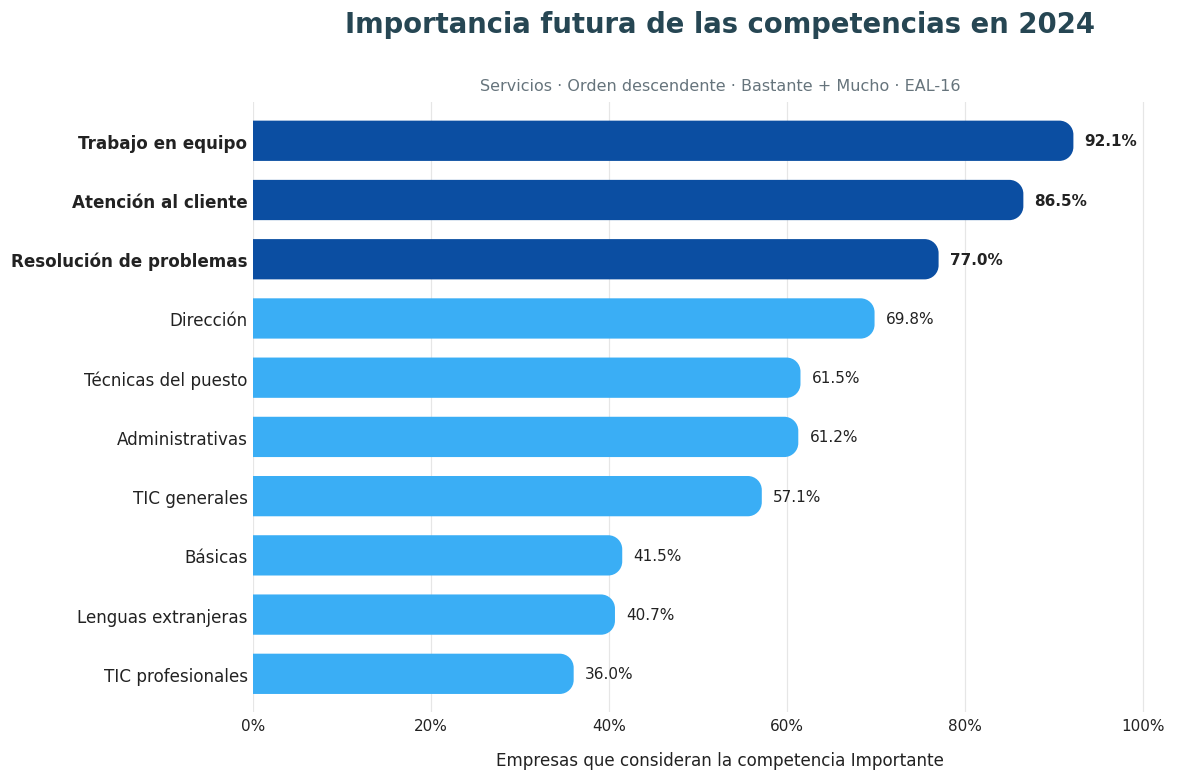

In [7]:
importancia_2024 = (
    importancia.query("anio == 2024")
    .sort_values("valor", ascending=False)
    .reset_index(drop=True)
)
importancia_2024["es_top_3"] = importancia_2024.index < 3

crear_grafico_barras_horizontales_perfil(
    tabla=importancia_2024,
    titulo="Importancia futura de las competencias en 2024",
    subtitulo=(
        "Servicios · Orden descendente · "
        "Bastante + Mucho · EAL-16"
    ),
    etiqueta_eje_x=(
        "Empresas que consideran la competencia "
        "Importante"
    ),
    limite_x=105,
    figsize=(11, 7.2),
)

#### Formación ofrecida en 2024

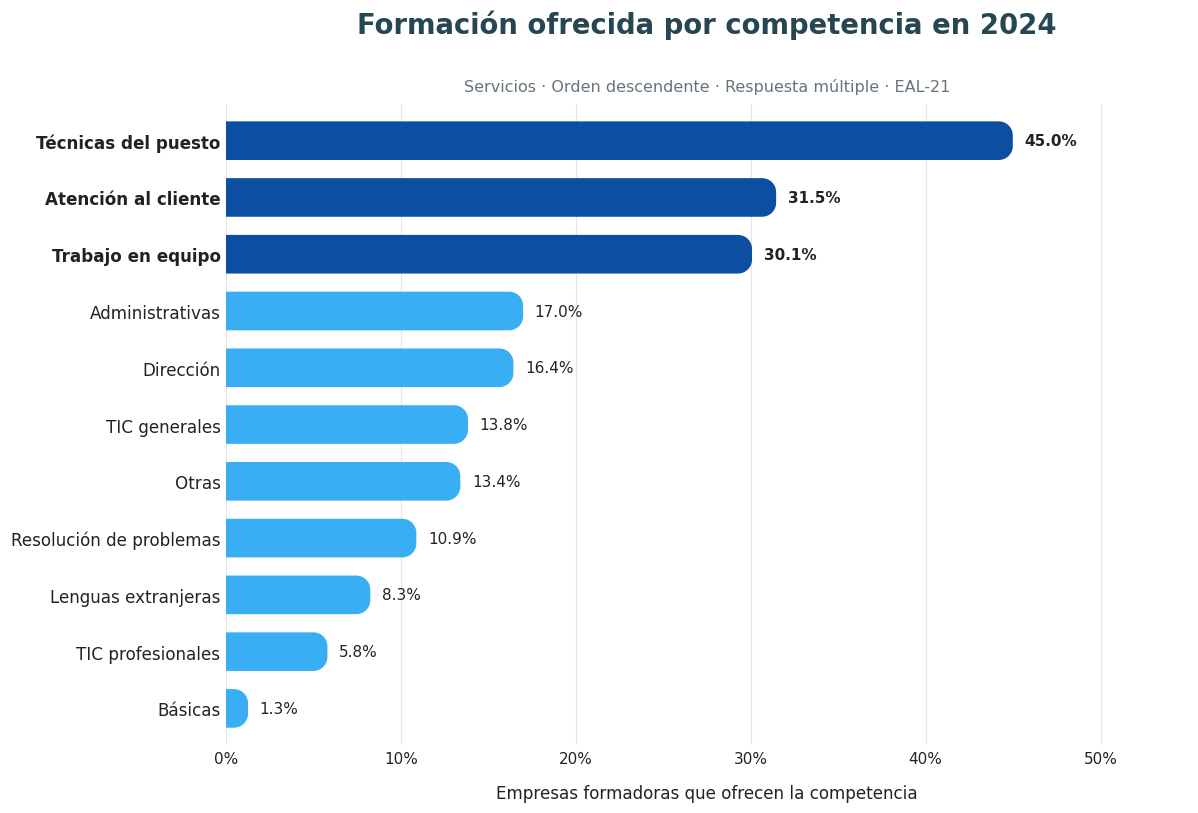

In [8]:
formacion_2024_barras = (
    formacion.query("anio == 2024")
    .sort_values("valor", ascending=False)
    .reset_index(drop=True)
)
formacion_2024_barras["es_top_3"] = formacion_2024_barras.index < 3

crear_grafico_barras_horizontales_perfil(
    tabla=formacion_2024_barras,
    titulo="Formación ofrecida por competencia en 2024",
    subtitulo=(
        "Servicios · Orden descendente · "
        "Respuesta múltiple · EAL-21"
    ),
    etiqueta_eje_x=(
        "Empresas formadoras que ofrecen la competencia"
    ),
    limite_x=55,
    figsize=(11, 7.5),
)

#### Nivel y estabilidad de la importancia futura

El mapa de calor permite comparar simultáneamente el nivel de cada competencia
y su estabilidad entre 2022 y 2024.

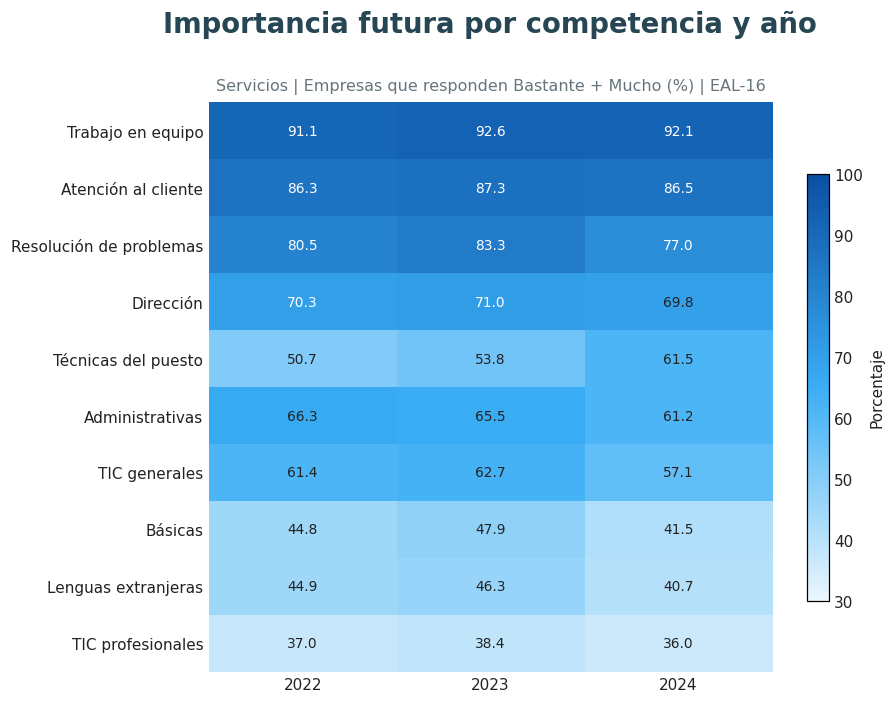

In [9]:
matriz_importancia = (
    importancia.pivot(index="competencia_id", columns="anio", values="valor")
               .loc[evol_importancia.sort_values(2024, ascending=False)["competencia_id"]]
)
etiquetas_y = [ETIQUETAS[idx] for idx in matriz_importancia.index]

fig, ax = plt.subplots(figsize=(8.5, 6.5))
imagen = ax.imshow(matriz_importancia.values, cmap=LinearSegmentedColormap.from_list(
        "azules_referencia", ["#EAF6FD", AZUL_CLARO, AZUL]
    ), vmin=30, vmax=100, aspect="auto")

for fila in range(matriz_importancia.shape[0]):
    for columna in range(matriz_importancia.shape[1]):
        valor = matriz_importancia.iloc[fila, columna]
        color = "white" if valor >= 70 else TINTA
        ax.text(columna, fila, f"{valor:.1f}", ha="center", va="center", color=color, fontsize=9)

ax.set_xticks(range(3), matriz_importancia.columns)
ax.set_yticks(range(len(etiquetas_y)), etiquetas_y)
ax.set_title("Importancia futura por competencia y año", loc="center", pad=46)
ax.text(
    0.5, 1.015, "Servicios | Empresas que responden Bastante + Mucho (%) | EAL-16", transform=ax.transAxes,
    ha="center", va="bottom", fontsize=10.5,
    color=GRIS)
ax.tick_params(length=0)
fig.colorbar(imagen, ax=ax, label="Porcentaje", shrink=0.75)
plt.tight_layout()
plt.show()

### 4. Evolución de posiciones y prioridades

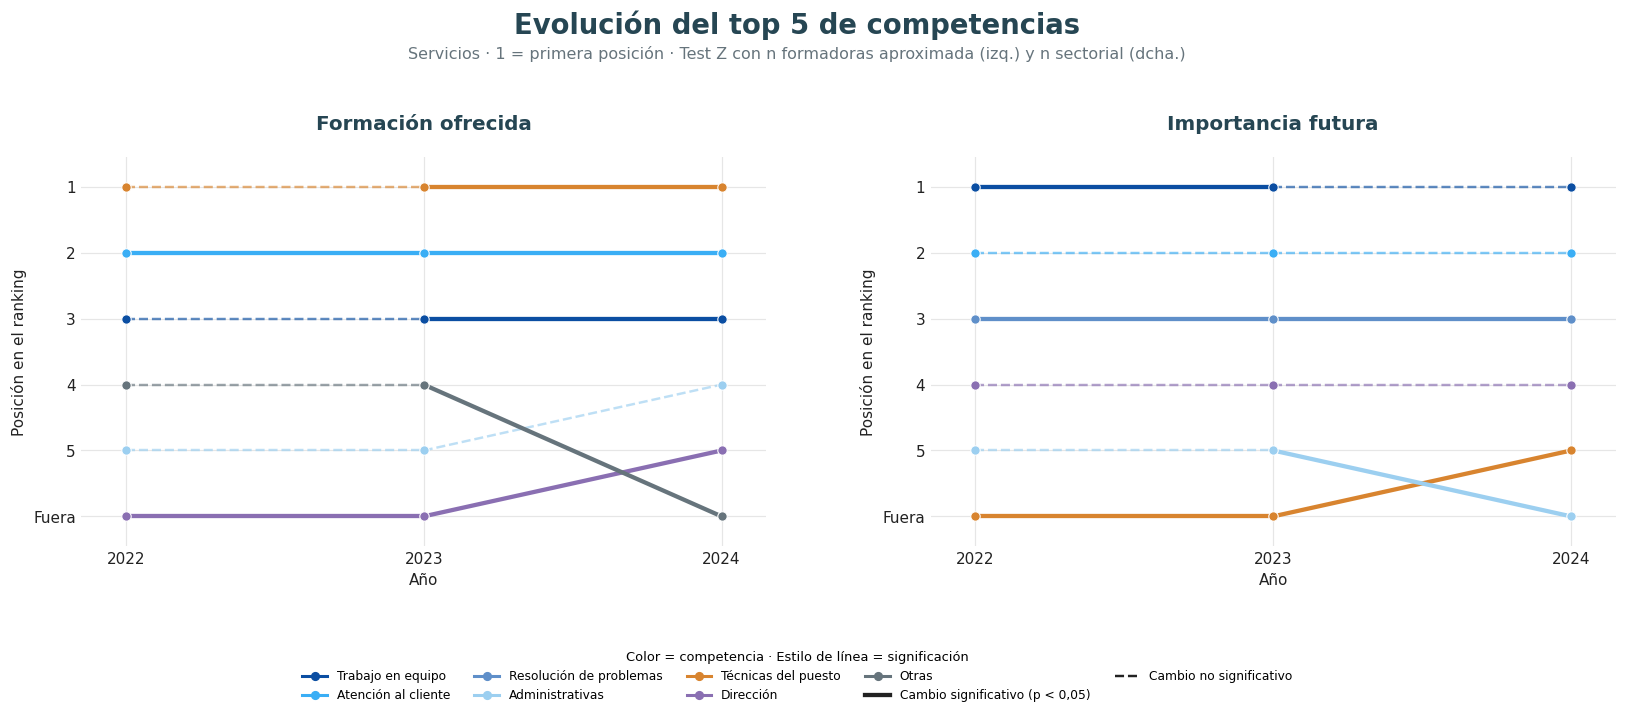

In [10]:
COLORES_TOP5_POR_COMPETENCIA = {
    "trabajo_equipo": AZUL,
    "atencion_clientes": AZUL_CLARO,
    "resolucion_problemas": "#5F8FC9",
    "administrativas_oficina": "#9CCFF0",
    "tecnicas_puesto": NARANJA,
    "direccion": "#8A6FB2",
    "otras": GRIS,
}

def panel_bump_top5(ax, tabla, titulo):
    ids_top5 = tabla.query("rank <= 5")["competencia_id"].drop_duplicates().tolist()
    orden_2024 = (
        tabla.query("anio == 2024 and competencia_id in @ids_top5")
             .sort_values("rank")["competencia_id"]
             .tolist()
    )
    orden = orden_2024 + [competencia for competencia in ids_top5 if competencia not in orden_2024]
    for competencia_id in orden:
        color = COLORES_TOP5_POR_COMPETENCIA[competencia_id]
        serie = (
            tabla.query("competencia_id == @competencia_id")
                 .sort_values("anio")
                 .set_index("anio")
                 .reindex([2022, 2023, 2024])
        )
        serie["rank_visible"] = serie["rank"].clip(upper=6)

        for anio_inicial, anio_final in [(2022, 2023), (2023, 2024)]:
            periodo = f"{anio_inicial}→{anio_final}"
            resultado_tramo = df_significacion.loc[
                (df_significacion["indicador"] == titulo)
                & (df_significacion["competencia_id"] == competencia_id)
                & (df_significacion["periodo"] == periodo)
            ]
            if len(resultado_tramo) != 1:
                raise ValueError(
                    f"Se esperaba un resultado de significación para "
                    f"{titulo}, {competencia_id}, {periodo}; encontrados: "
                    f"{len(resultado_tramo)}"
                )
            es_significativo = bool(resultado_tramo.iloc[0]["cambio_significativo"])
            ax.plot(
                [anio_inicial, anio_final],
                [serie.loc[anio_inicial, "rank_visible"], serie.loc[anio_final, "rank_visible"]],
                color=color,
                linewidth=2.8 if es_significativo else 1.6,
                linestyle="-" if es_significativo else "--",
                alpha=1.0 if es_significativo else 0.65,
                zorder=2,
            )

        ax.scatter(
            [2022, 2023, 2024],
            serie["rank_visible"],
            s=38,
            color=color,
            edgecolor="white",
            linewidth=0.7,
            zorder=3,
        )
    ax.set_xlim(2021.85, 2024.15)
    ax.set_ylim(6.45, 0.55)
    ax.set_xticks([2022, 2023, 2024])
    ax.set_yticks([1, 2, 3, 4, 5, 6], ["1", "2", "3", "4", "5", "Fuera"])
    ax.set_xlabel("Año")
    ax.set_ylabel("Posición en el ranking")
    ax.set_title(
        titulo, loc="center", fontsize=13, fontweight="bold",
        color=COLOR_TITULO_BARRAS, pad=18,
    )
    ax.grid(color=COLOR_GRID_BARRAS, linewidth=0.8, alpha=0.65)
    return orden

fig, ejes = plt.subplots(1, 2, figsize=(15.5, 6.2))
orden_formacion_top5 = panel_bump_top5(
    ejes[0], formacion, "Formación ofrecida"
)
orden_importancia_top5 = panel_bump_top5(
    ejes[1], importancia, "Importancia futura"
)
fig.suptitle(
    "Evolución del top 5 de competencias",
    x=0.5, y=1.035, ha="center", fontsize=18,
    fontweight="bold", color=COLOR_TITULO_BARRAS,
)
fig.text(
    0.5, 0.965,
    "Servicios · 1 = primera posición · Test Z con n formadoras "
    "aproximada (izq.) y n sectorial (dcha.)",
    ha="center", color=GRIS, fontsize=10.5,
)
competencias_visibles_top5 = [
    competencia_id
    for competencia_id in COLORES_TOP5_POR_COMPETENCIA
    if competencia_id in set(orden_formacion_top5 + orden_importancia_top5)
]
handles_leyenda_top5 = [
    Line2D(
        [0], [0],
        color=COLORES_TOP5_POR_COMPETENCIA[competencia_id],
        marker="o",
        linewidth=2,
        markersize=5,
        label=ETIQUETAS[competencia_id],
    )
    for competencia_id in competencias_visibles_top5
]
handles_leyenda_top5.extend([
    Line2D(
        [0], [0], color=TINTA, linewidth=2.8, linestyle="-",
        label="Cambio significativo (p < 0,05)",
    ),
    Line2D(
        [0], [0], color=TINTA, linewidth=1.6, linestyle="--",
        label="Cambio no significativo",
    ),
])
fig.legend(
    handles=handles_leyenda_top5,
    title="Color = competencia · Estilo de línea = significación",
    frameon=False,
    ncol=5,
    loc="lower center",
    bbox_to_anchor=(0.5, 0.005),
    fontsize=8,
    title_fontsize=8.5,
)
fig.subplots_adjust(top=0.82, bottom=0.25, left=0.08, right=0.98, wspace=0.24)
plt.show()

**Lectura.** La significación se evalúa sobre el porcentaje de cada competencia, aunque el eje muestre su posición en el ranking. Por tanto, una competencia puede conservar el mismo puesto y presentar un cambio porcentual significativo, o cambiar de puesto sin que su variación porcentual sea significativa. En Formación ofrecida se utiliza una muestra formadora aproximada a partir de EAL-C1 y EAL-17/EAL-18a.

#### Evolución del ranking completo de formación ofrecida

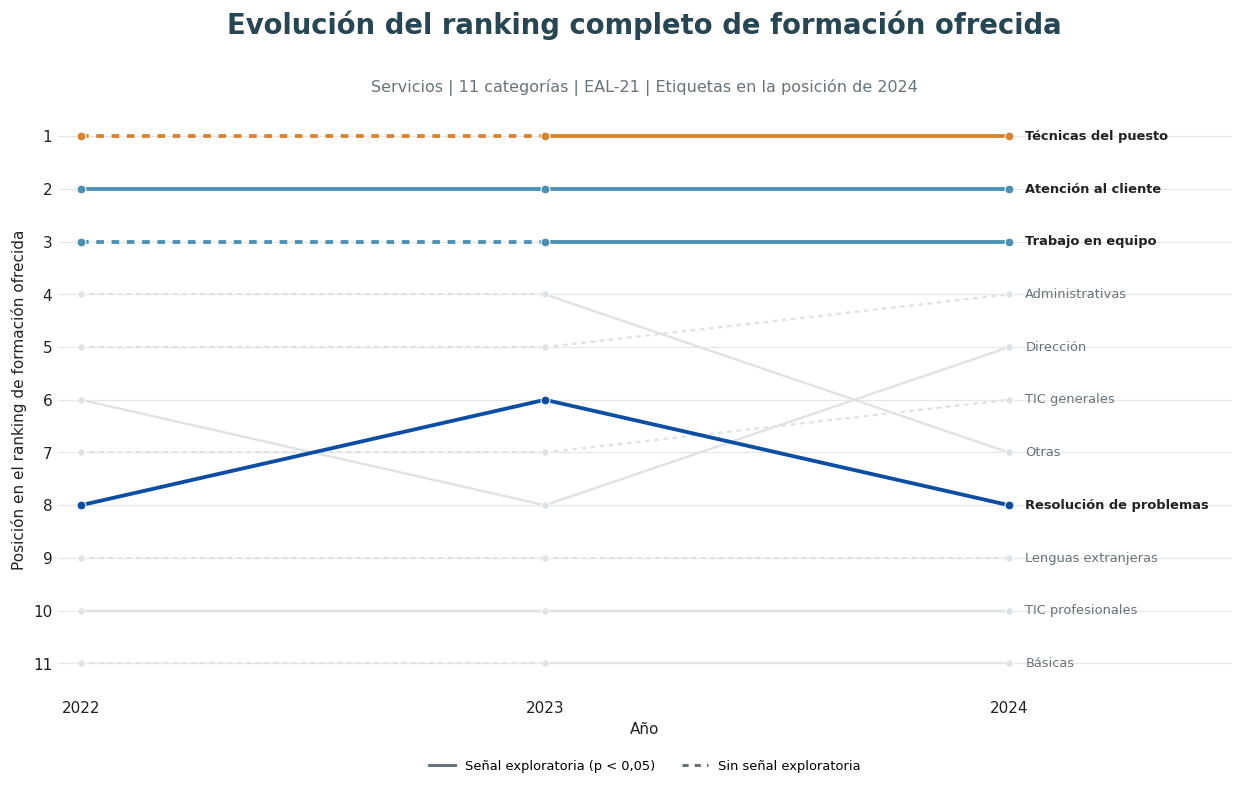

In [11]:
ranking_formacion_pivot = formacion.pivot(
    index="competencia_id", columns="anio", values="rank"
)

significacion_formacion = diccionario_significacion("Formación ofrecida")

competencias_foco = {
    "tecnicas_puesto": NARANJA,
    "resolucion_problemas": AZUL,
    "trabajo_equipo": "#4C91B3",
    "atencion_clientes": "#4C91B3",
}

fig, ax = plt.subplots(figsize=(11.5, 7.8))
for competencia_id, rangos in ranking_formacion_pivot.iterrows():
    color = competencias_foco.get(competencia_id, GRIS_CLARO)
    ancho = 2.5 if competencia_id in competencias_foco else 1.5
    zorder = 3 if competencia_id in competencias_foco else 2

    for anio_inicial, anio_final in zip(ANIOS[:-1], ANIOS[1:]):
        periodo = f"{anio_inicial}→{anio_final}"
        es_significativo = bool(
            significacion_formacion.get((competencia_id, periodo), False)
        )
        ax.plot(
            [anio_inicial, anio_final],
            [rangos[anio_inicial], rangos[anio_final]],
            color=color,
            linewidth=ancho,
            linestyle="-" if es_significativo else (0, (2, 2)),
            solid_capstyle="round",
            zorder=zorder,
        )

    ax.scatter(
        ANIOS,
        [rangos[anio] for anio in ANIOS],
        s=34 if competencia_id in competencias_foco else 24,
        color=color,
        edgecolor="white",
        linewidth=0.7,
        zorder=zorder + 1,
    )
    ax.text(
        2024.035,
        rangos[2024],
        ETIQUETAS[competencia_id],
        va="center",
        fontsize=8.5,
        fontweight="bold" if competencia_id in competencias_foco else "normal",
        color=TINTA if competencia_id in competencias_foco else GRIS,
    )

ax.set_xlim(2021.95, 2024.48)
ax.set_ylim(11.6, 0.4)
ax.set_xticks(ANIOS)
ax.set_yticks(range(1, 12))
ax.set_xlabel("Año")
ax.set_ylabel("Posición en el ranking de formación ofrecida")
ax.set_title("Evolución del ranking completo de formación ofrecida", loc="center", pad=46)
ax.text(
    0.5, 1.015,
    "Servicios | 11 categorías | EAL-21 | Etiquetas en la posición de 2024",
    transform=ax.transAxes,
    ha="center", va="bottom", fontsize=10.5,
    color=GRIS,
)
ax.grid(axis="y", color=COLOR_GRID_BARRAS, linewidth=0.8, alpha=0.65)
ax.grid(axis="x", visible=False)

leyenda_significacion = [
    Line2D([0], [0], color=GRIS, linewidth=2, linestyle="-",
           label="Señal exploratoria (p < 0,05)"),
    Line2D([0], [0], color=GRIS, linewidth=2, linestyle=(0, (2, 2)),
           label="Sin señal exploratoria"),
]
ax.legend(
    handles=leyenda_significacion,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.09),
    ncol=2,
    fontsize=8.5,
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

#### Evolución porcentual de la importancia futura

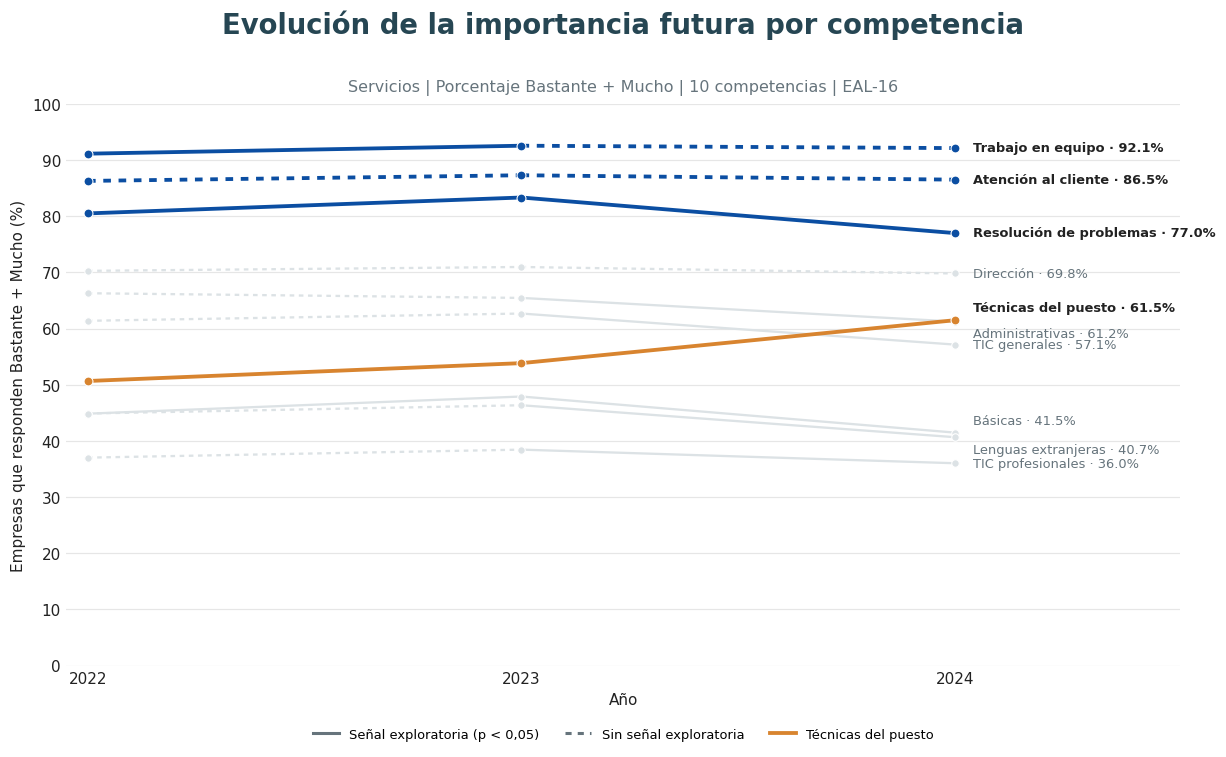

In [12]:
porcentaje_importancia_pivot = importancia.pivot(
    index="competencia_id", columns="anio", values="valor"
)

significacion_importancia = diccionario_significacion("Importancia futura")

competencias_foco_importancia = {
    "trabajo_equipo": AZUL,
    "atencion_clientes": AZUL,
    "resolucion_problemas": AZUL,
    "tecnicas_puesto": NARANJA,
}
desplazamiento_etiquetas = {
    "tecnicas_puesto": 8,
    "administrativas_oficina": -8,
    "basicas_calculo_comunicacion": 8,
    "lenguas_extranjeras": -8,
}

fig, ax = plt.subplots(figsize=(11.5, 7.5))
for competencia_id, porcentajes in porcentaje_importancia_pivot.iterrows():
    color = competencias_foco_importancia.get(competencia_id, GRIS_CLARO)
    ancho = 2.5 if competencia_id in competencias_foco_importancia else 1.5
    zorder = 3 if competencia_id in competencias_foco_importancia else 2

    for anio_inicial, anio_final in zip(ANIOS[:-1], ANIOS[1:]):
        periodo = f"{anio_inicial}→{anio_final}"
        es_significativo = bool(
            significacion_importancia.get((competencia_id, periodo), False)
        )
        ax.plot(
            [anio_inicial, anio_final],
            [porcentajes[anio_inicial], porcentajes[anio_final]],
            color=color,
            linewidth=ancho,
            linestyle="-" if es_significativo else (0, (2, 2)),
            solid_capstyle="round",
            zorder=zorder,
        )

    ax.scatter(
        ANIOS,
        [porcentajes[anio] for anio in ANIOS],
        s=34 if competencia_id in competencias_foco_importancia else 24,
        color=color,
        edgecolor="white",
        linewidth=0.7,
        zorder=zorder + 1,
    )
    valor_2024 = porcentajes[2024]
    ax.annotate(
        f"{ETIQUETAS[competencia_id]} · {valor_2024:.1f}%",
        xy=(2024, valor_2024),
        xytext=(12, desplazamiento_etiquetas.get(competencia_id, 0)),
        textcoords="offset points",
        va="center",
        fontsize=8.5,
        fontweight="bold" if competencia_id in competencias_foco_importancia else "normal",
        color=TINTA if competencia_id in competencias_foco_importancia else GRIS,
    )

ax.set_xlim(2021.95, 2024.52)
ax.set_ylim(0, 100)
ax.set_xticks(ANIOS)
ax.set_yticks(range(0, 101, 10))
ax.set_xlabel("Año")
ax.set_ylabel("Empresas que responden Bastante + Mucho (%)")
ax.set_title("Evolución de la importancia futura por competencia", loc="center", pad=46)
ax.text(
    0.5, 1.015,
    "Servicios | Porcentaje Bastante + Mucho | 10 competencias | EAL-16",
    transform=ax.transAxes,
    ha="center", va="bottom", fontsize=10.5,
    color=GRIS,
)
ax.grid(axis="y", color=COLOR_GRID_BARRAS, linewidth=0.8, alpha=0.65)
ax.grid(axis="x", visible=False)

leyenda_importancia = [
    Line2D([0], [0], color=GRIS, linewidth=2, linestyle="-",
           label="Señal exploratoria (p < 0,05)"),
    Line2D([0], [0], color=GRIS, linewidth=2, linestyle=(0, (2, 2)),
           label="Sin señal exploratoria"),
    Line2D([0], [0], color=NARANJA, linewidth=2.5,
           label="Técnicas del puesto"),
]
ax.legend(
    handles=leyenda_importancia,
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.09),
    ncol=3,
    fontsize=8.5,
)
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

### 5. Evolución de la cartera de formación

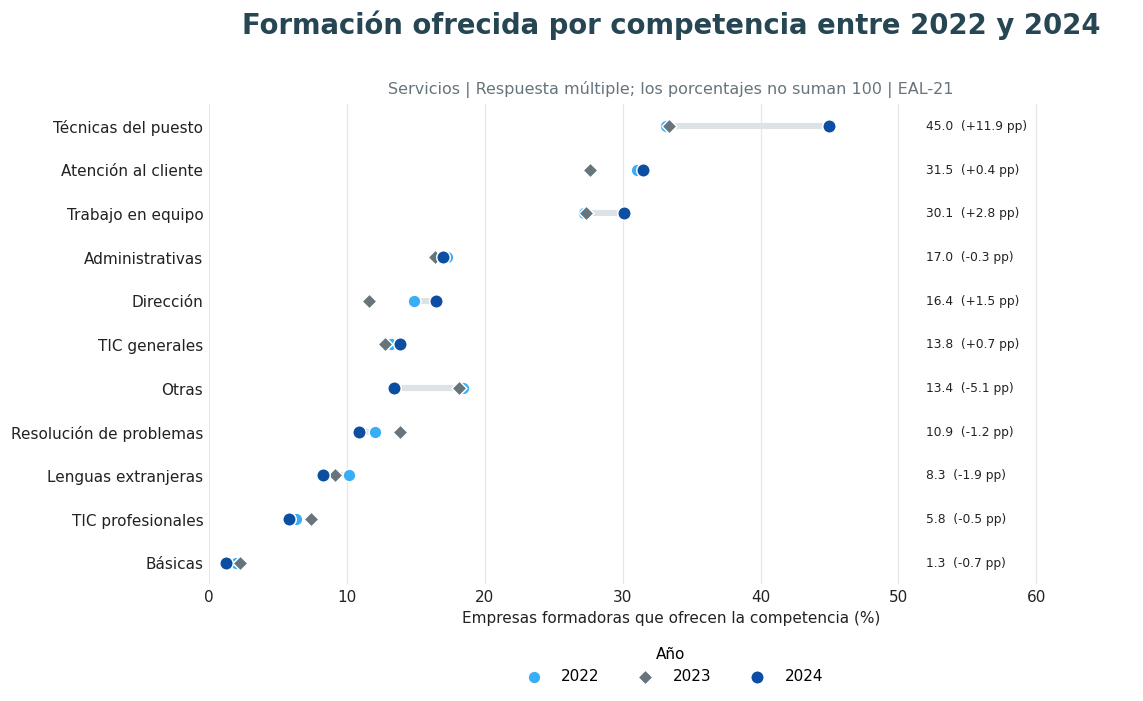

In [13]:
orden_formacion = (
    formacion.query("anio == 2024")
             .sort_values("valor")["competencia_id"]
             .tolist()
)
formacion_tres_anios = (
    formacion.pivot(index="competencia_id", columns="anio", values="valor")
             .reindex(orden_formacion)
)
etiquetas_formacion = [ETIQUETAS[competencia] for competencia in orden_formacion]

y = np.arange(len(formacion_tres_anios))
fig, ax = plt.subplots(figsize=(10.5, 7.0))
for posicion, (_, fila) in enumerate(formacion_tres_anios.iterrows()):
    ax.plot([fila[2022], fila[2024]], [posicion, posicion], color=GRIS_CLARO, linewidth=4, zorder=1)

ax.scatter(formacion_tres_anios[2022], y, s=70, color=AZUL_CLARO, edgecolor="white", label="2022", zorder=3)
ax.scatter(formacion_tres_anios[2023], y, s=48, color=GRIS, marker="D", edgecolor="white", label="2023", zorder=4)
ax.scatter(formacion_tres_anios[2024], y, s=78, color=AZUL, edgecolor="white", label="2024", zorder=5)

for posicion, (_, fila) in enumerate(formacion_tres_anios.iterrows()):
    cambio = fila[2024] - fila[2022]
    ax.text(
        52, posicion, f"{fila[2024]:.1f}  ({cambio:+.1f} pp)",
        ha="left", va="center", fontsize=8, color=TINTA,
    )

ax.set_yticks(y, etiquetas_formacion)
ax.set_xlim(0, 67)
ax.set_xlabel("Empresas formadoras que ofrecen la competencia (%)")
ax.set_ylabel("")
ax.set_title("Formación ofrecida por competencia entre 2022 y 2024", loc="center", pad=46)
ax.text(
    0.5, 1.015,
    "Servicios | Respuesta múltiple; los porcentajes no suman 100 | EAL-21",
    transform=ax.transAxes,
    ha="center", va="bottom", fontsize=10.5,
    color=GRIS,
)
ax.grid(axis="x", color=COLOR_GRID_BARRAS, linewidth=0.8, alpha=0.65)
ax.legend(title="Año", frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, -0.10))
plt.tight_layout(rect=[0, 0.06, 1, 1])
plt.show()

### 6. Cambios acumulados entre 2022 y 2024

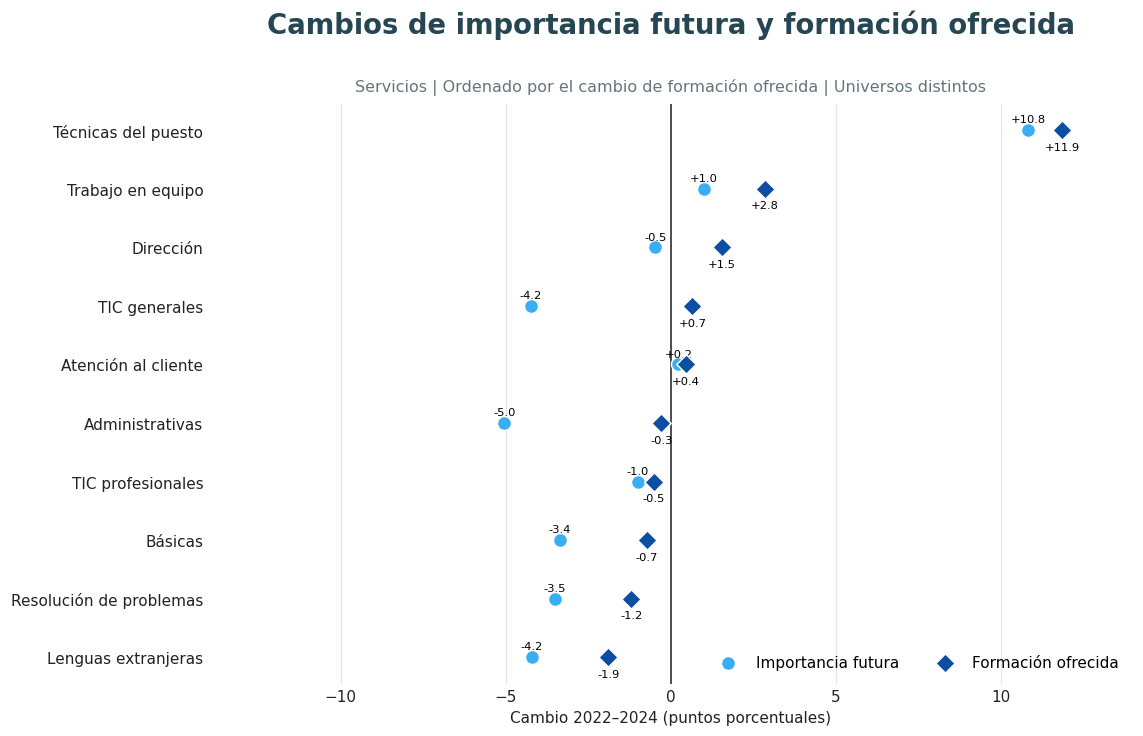

#### Evolución de la importancia futura

anio,competencia,2022,2023,2024,cambio_22_23_pp,cambio_23_24_pp,cambio_22_24_pp,magnitud_22_24
6,Competencias técnicas del puesto de trabajo,50.70,53.80,61.50,3.20,7.60,10.80,Notable (≥5 pp)
9,Trabajo en equipo,91.10,92.60,92.10,1.40,-0.40,1.00,Estable (<2 pp)
1,Atención al público / trato a clientes,86.30,87.30,86.50,1.00,-0.80,0.20,Estable (<2 pp)
3,Dirección,70.30,71.00,69.80,0.70,-1.20,-0.50,Estable (<2 pp)
8,Profesionales de tecnologías de la información,37.00,38.40,36.00,1.40,-2.40,-1.00,Estable (<2 pp)
2,Básicas de cálculo y/o comunicación oral o escrita,44.80,47.90,41.50,3.10,-6.40,-3.40,Moderado (2–<5 pp)
5,Resolución de problemas,80.50,83.30,77.00,2.80,-6.30,-3.50,Moderado (2–<5 pp)
4,Lenguas extranjeras,44.90,46.30,40.70,1.50,-5.70,-4.20,Moderado (2–<5 pp)
7,Generales de tecnologías de la información,61.40,62.70,57.10,1.30,-5.50,-4.20,Moderado (2–<5 pp)
0,Administrativas de oficina,66.30,65.50,61.20,-0.80,-4.20,-5.00,Notable (≥5 pp)


#### Evolución de la formación ofrecida

anio,competencia,2022,2023,2024,cambio_22_23_pp,cambio_23_24_pp,cambio_22_24_pp,magnitud_22_24
7,Competencias técnicas del puesto de trabajo,33.10,33.40,45.00,0.30,11.60,11.90,Notable (≥5 pp)
10,Trabajo en equipo,27.20,27.30,30.10,0.10,2.80,2.80,Moderado (2–<5 pp)
3,Dirección,14.90,11.60,16.40,-3.30,4.80,1.50,Estable (<2 pp)
8,Generales de tecnologías de la información,13.20,12.80,13.80,-0.40,1.10,0.70,Estable (<2 pp)
1,Atención al público / trato a clientes,31.00,27.70,31.50,-3.30,3.80,0.40,Estable (<2 pp)
0,Administrativas de oficina,17.30,16.40,17.00,-0.80,0.60,-0.30,Estable (<2 pp)
9,Profesionales de tecnologías de la información,6.30,7.40,5.80,1.10,-1.60,-0.50,Estable (<2 pp)
2,Básicas de cálculo y/o comunicación oral o escrita,2.00,2.30,1.30,0.30,-1.00,-0.70,Estable (<2 pp)
6,Resolución de problemas,12.10,13.90,10.90,1.80,-3.00,-1.20,Estable (<2 pp)
4,Lenguas extranjeras,10.20,9.10,8.30,-1.00,-0.90,-1.90,Estable (<2 pp)


In [14]:
comparacion_cambios = (
    evol_importancia[["competencia_id", "etiqueta", "cambio_22_24_pp"]]
    .rename(columns={"cambio_22_24_pp": "Importancia futura"})
    .merge(
        evol_formacion.query("competencia_id != 'otras'")[
            ["competencia_id", "cambio_22_24_pp"]
        ].rename(columns={"cambio_22_24_pp": "Formación ofrecida"}),
        on="competencia_id",
        validate="one_to_one",
    )
    .sort_values("Formación ofrecida")
)

y = np.arange(len(comparacion_cambios))

fig, ax = plt.subplots(figsize=(10.5, 6.8))
ax.scatter(
    comparacion_cambios["Importancia futura"], y,
    s=85, color=AZUL_CLARO, edgecolor="white", label="Importancia futura", zorder=3,
)
ax.scatter(
    comparacion_cambios["Formación ofrecida"], y,
    s=80, color=AZUL, marker="D", edgecolor="white", label="Formación ofrecida", zorder=4,
)

ax.axvline(0, color=TINTA, linewidth=1)
ax.set_yticks(y, comparacion_cambios["etiqueta"])
ax.set_xlim(-14, 14)
ax.set_xlabel("Cambio 2022–2024 (puntos porcentuales)")
ax.set_ylabel("")
ax.set_title("Cambios de importancia futura y formación ofrecida", loc="center", pad=46)
ax.text(
    0.5, 1.015,
    "Servicios | Ordenado por el cambio de formación ofrecida | Universos distintos",
    transform=ax.transAxes,
    ha="center", va="bottom", fontsize=10.5,
    color=GRIS,
)
ax.grid(axis="x", color=COLOR_GRID_BARRAS, linewidth=0.8, alpha=0.65)
ax.legend(frameon=False, ncol=2, loc="lower right")

for columna, desplazamiento_y in [("Importancia futura", 7), ("Formación ofrecida", -11)]:
    for posicion, valor in enumerate(comparacion_cambios[columna]):
        ax.annotate(
            f"{valor:+.1f}", (valor, posicion),
            xytext=(0, desplazamiento_y), textcoords="offset points",
            ha="center", va="center", fontsize=7.5,
        )

plt.tight_layout()
plt.show()

display(Markdown("#### Evolución de la importancia futura"))
display(evol_importancia.sort_values("cambio_22_24_pp", ascending=False)[
    ["competencia", 2022, 2023, 2024, "cambio_22_23_pp", "cambio_23_24_pp", "cambio_22_24_pp", "magnitud_22_24"]
].round(1))

display(Markdown("#### Evolución de la formación ofrecida"))
display(evol_formacion.sort_values("cambio_22_24_pp", ascending=False)[
    ["competencia", 2022, 2023, 2024, "cambio_22_23_pp", "cambio_23_24_pp", "cambio_22_24_pp", "magnitud_22_24"]
].round(1))

### 7. Señales estadísticas entre años

In [15]:
resumen_significacion = (
    df_significacion.groupby(["indicador", "periodo"], as_index=False)
    .agg(
        competencias_contrastadas=("competencia_id", "size"),
        cambios_significativos=("cambio_significativo", "sum"),
    )
)

display(Markdown("#### Derivación del denominador de empresas formadoras"))
display(
    estimacion_formadoras.style.format({
        "empresas_servicios_marco": "{:,.0f}",
        "empresas_formadoras_estimadas": "{:,.0f}",
        "porcentaje_formadoras_servicios": "{:.1f}%",
        "muestra_servicios": "{:,.0f}",
        "muestra_formadoras_aproximada": "{:,.0f}",
    })
)

display(Markdown("#### Resumen de los contrastes"))
display(resumen_significacion)

display(Markdown("#### Resultados por competencia"))
tabla_significacion = df_significacion[[
    "indicador", "competencia", "periodo", "%_inicio", "%_fin",
    "variacion_pp", "p_valor", "Señal exploratoria (p<0,05)",
    "calidad_inferencia",
]]
display(
    tabla_significacion.style.format({
        "%_inicio": "{:.1f}",
        "%_fin": "{:.1f}",
        "variacion_pp": "{:+.1f}",
        "p_valor": lambda valor: "<0,0001" if valor < 0.0001 else f"{valor:.4f}".replace(".", ","),
    })
)

significativos_importancia = df_significacion.query(
    "indicador == 'Importancia futura' and cambio_significativo"
).copy()
display(Markdown("#### Señales exploratorias en importancia futura"))
if significativos_importancia.empty:
    display(Markdown("No se detectan cambios con `p < 0,05`."))
else:
    tabla_sig_importancia = significativos_importancia[[
        "competencia", "periodo", "variacion_pp", "p_valor"
    ]]
    display(
        tabla_sig_importancia.style.format({
            "variacion_pp": "{:+.1f}",
            "p_valor": lambda valor: "<0,0001" if valor < 0.0001 else f"{valor:.4f}".replace(".", ","),
        })
    )

#### Derivación del denominador de empresas formadoras

,anio,fuente_porcentaje,empresas_servicios_marco,empresas_formadoras_estimadas,porcentaje_formadoras_servicios,muestra_servicios,muestra_formadoras_aproximada
0,2022,EAL-17,"240,073","167,289",69.7%,"6,266","4,366"
1,2023,EAL-18a,"249,302","176,094",70.6%,"6,107","4,314"
2,2024,EAL-18a,"255,054","184,018",72.1%,"5,963","4,302"


#### Resumen de los contrastes

,indicador,periodo,competencias_contrastadas,cambios_significativos
0,Formación ofrecida,2022→2023,11,4
1,Formación ofrecida,2023→2024,11,8
2,Importancia futura,2022→2023,10,4
3,Importancia futura,2023→2024,10,7


#### Resultados por competencia

,indicador,competencia,periodo,%_inicio,%_fin,variacion_pp,p_valor,"Señal exploratoria (p<0,05)",calidad_inferencia
0,Formación ofrecida,Dirección,2022→2023,14.9,11.6,-3.3,"<0,0001",Sí,Test Z exploratorio con n formadoras aproximada
1,Formación ofrecida,Atención al público / trato a clientes,2022→2023,31.0,27.7,-3.3,"0,0006",Sí,Test Z exploratorio con n formadoras aproximada
2,Formación ofrecida,Resolución de problemas,2022→2023,12.1,13.9,+1.8,"0,0142",Sí,Test Z exploratorio con n formadoras aproximada
3,Formación ofrecida,Profesionales de tecnologías de la información,2022→2023,6.3,7.4,+1.1,"0,0435",Sí,Test Z exploratorio con n formadoras aproximada
4,Formación ofrecida,Lenguas extranjeras,2022→2023,10.2,9.1,-1.0,"0,1021",No,Test Z exploratorio con n formadoras aproximada
5,Formación ofrecida,Administrativas de oficina,2022→2023,17.3,16.4,-0.8,"0,2988",No,Test Z exploratorio con n formadoras aproximada
6,Formación ofrecida,Básicas de cálculo y/o comunicación oral o escrita,2022→2023,2.0,2.3,+0.3,"0,4081",No,Test Z exploratorio con n formadoras aproximada
7,Formación ofrecida,Generales de tecnologías de la información,2022→2023,13.2,12.8,-0.4,"0,5601",No,Test Z exploratorio con n formadoras aproximada
8,Formación ofrecida,Otras,2022→2023,18.5,18.1,-0.3,"0,6875",No,Test Z exploratorio con n formadoras aproximada
9,Formación ofrecida,Competencias técnicas del puesto de trabajo,2022→2023,33.1,33.4,+0.3,"0,7794",No,Test Z exploratorio con n formadoras aproximada


#### Señales exploratorias en importancia futura

,competencia,periodo,variacion_pp,p_valor
22,Resolución de problemas,2022→2023,+2.8,"<0,0001"
23,Competencias técnicas del puesto de trabajo,2022→2023,+3.2,"0,0004"
24,Básicas de cálculo y/o comunicación oral o escrita,2022→2023,+3.1,"0,0007"
25,Trabajo en equipo,2022→2023,+1.4,"0,0043"
32,Resolución de problemas,2023→2024,-6.3,"<0,0001"
33,Competencias técnicas del puesto de trabajo,2023→2024,+7.6,"<0,0001"
34,Básicas de cálculo y/o comunicación oral o escrita,2023→2024,-6.4,"<0,0001"
35,Lenguas extranjeras,2023→2024,-5.7,"<0,0001"
36,Generales de tecnologías de la información,2023→2024,-5.5,"<0,0001"
37,Administrativas de oficina,2023→2024,-4.2,"<0,0001"


### 8. Alineamiento entre importancia y formación

In [16]:
imp_alinear = importancia.rename(columns={"valor": "importancia", "rank": "rank_importancia"})[
    ["anio", "competencia_id", "competencia", "etiqueta", "importancia", "rank_importancia"]
]
for_alinear = formacion.query("competencia_id != 'otras'").rename(
    columns={"valor": "formacion"}
)[["anio", "competencia_id", "formacion"]]
for_alinear["rank_formacion"] = (
    for_alinear.groupby("anio")["formacion"]
               .rank(ascending=False, method="min")
               .astype(int)
)

alineamiento = imp_alinear.merge(
    for_alinear,
    on=["anio", "competencia_id"],
    validate="one_to_one",
)
alineamiento["pct_importancia"] = alineamiento.groupby("anio")["importancia"].rank(pct=True)
alineamiento["pct_formacion"] = alineamiento.groupby("anio")["formacion"].rank(pct=True)
alineamiento["brecha_relativa"] = alineamiento["pct_importancia"] - alineamiento["pct_formacion"]

def accion(fila):
    alta_imp = fila["rank_importancia"] <= 5
    alta_for = fila["rank_formacion"] <= 5
    if alta_imp and not alta_for:
        return "Ampliar"
    if alta_imp and alta_for:
        return "Mantener / reforzar"
    if not alta_imp and alta_for:
        return "Revisar"
    return "Prioridad secundaria"

alineamiento["accion"] = alineamiento.apply(accion, axis=1)
datos_2024 = alineamiento.query("anio == 2024").copy()

orden_acciones_sector = [
    "Ampliar",
    "Mantener / reforzar",
    "Revisar",
    "Prioridad secundaria",
]
codigo_accion_sector = {
    accion_nombre: codigo
    for codigo, accion_nombre in enumerate(orden_acciones_sector)
}

COLORES_ACCION = {
    "Ampliar": AZUL,
    "Mantener / reforzar": AZUL_CLARO,
    "Revisar": "#7A8790",
    "Prioridad secundaria": "#C8D2D8",
}

resumen_alineamiento = []
for anio, grupo in alineamiento.groupby("anio"):
    top3_imp = set(grupo.nsmallest(3, "rank_importancia")["competencia_id"])
    top3_for = set(grupo.nsmallest(3, "rank_formacion")["competencia_id"])
    top5_imp = set(grupo.nsmallest(5, "rank_importancia")["competencia_id"])
    top5_for = set(grupo.nsmallest(5, "rank_formacion")["competencia_id"])
    resumen_alineamiento.append({
        "anio": anio,
        "spearman": grupo["importancia"].corr(grupo["formacion"], method="spearman"),
        "coincidencia_top_3": f"{len(top3_imp & top3_for)}/3",
        "coincidencia_top_5": f"{len(top5_imp & top5_for)}/5",
    })

display(pd.DataFrame(resumen_alineamiento).round(2))

,anio,spearman,coincidencia_top_3,coincidencia_top_5
0,2022,0.64,2/3,4/5
1,2023,0.64,2/3,4/5
2,2024,0.71,2/3,4/5


#### Alineamiento de rankings y acción en 2024

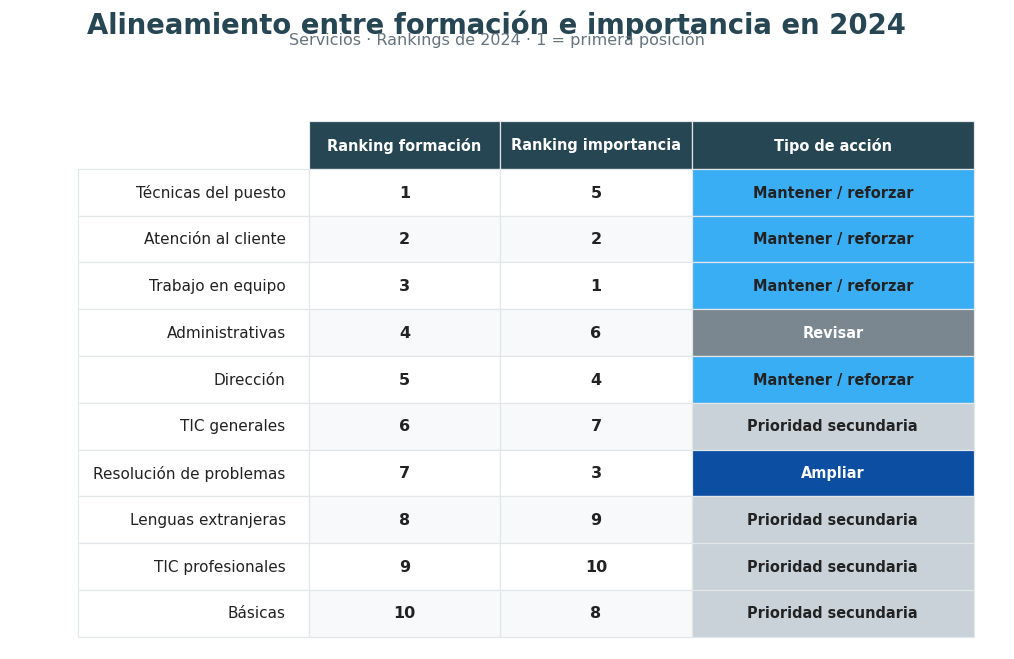

In [17]:
alineamiento_2024 = (
    alineamiento.query("anio == 2024")
    .copy()
    .assign(
        codigo_accion=lambda tabla: tabla["accion"].map(
            codigo_accion_sector
        )
    )
    .sort_values(["rank_formacion", "rank_importancia"])
    .reset_index(drop=True)
)

filas_tabla_alineamiento = [
    [
        f'{int(fila["rank_formacion"])}',
        f'{int(fila["rank_importancia"])}',
        fila["accion"],
    ]
    for _, fila in alineamiento_2024.iterrows()
]
etiquetas_filas_alineamiento = alineamiento_2024["etiqueta"].tolist()

colores_celdas_alineamiento = []
for posicion, (_, fila) in enumerate(alineamiento_2024.iterrows()):
    fondo_ranking = "#FFFFFF" if posicion % 2 == 0 else "#F7F9FA"
    colores_celdas_alineamiento.append([
        fondo_ranking,
        fondo_ranking,
        COLORES_ACCION[fila["accion"]],
    ])

fig, ax = plt.subplots(figsize=(9.6, 6.2))
ax.axis("off")

tabla_alineamiento_2024 = ax.table(
    cellText=filas_tabla_alineamiento,
    rowLabels=etiquetas_filas_alineamiento,
    colLabels=[
        "Ranking formación",
        "Ranking importancia",
        "Tipo de acción",
    ],
    cellColours=colores_celdas_alineamiento,
    colColours=[
        COLOR_TITULO_BARRAS,
        COLOR_TITULO_BARRAS,
        COLOR_TITULO_BARRAS,
    ],
    cellLoc="center",
    rowLoc="right",
    colWidths=[0.19, 0.19, 0.28],
    bbox=[0.30, 0.02, 0.67, 0.90],
)
tabla_alineamiento_2024.auto_set_font_size(False)
tabla_alineamiento_2024.set_fontsize(9.5)

for (fila, columna), celda in tabla_alineamiento_2024.get_celld().items():
    celda.set_edgecolor("#E3E7EA")
    celda.set_linewidth(0.8)

    if fila == 0:
        celda.set_text_props(
            color="white",
            fontweight="bold",
            fontsize=9.5,
        )
        celda.set_height(0.075)
        continue

    celda.set_height(0.073)
    if columna == -1:
        celda.set_facecolor("#FFFFFF")
        celda.set_text_props(
            color=COLOR_TEXTO_BARRAS,
            fontsize=10,
            ha="right",
        )
    elif columna in [0, 1]:
        celda.set_text_props(
            color=COLOR_TEXTO_BARRAS,
            fontsize=10.5,
            fontweight="bold",
        )
    elif columna == 2:
        codigo = int(
            alineamiento_2024.iloc[fila - 1]["codigo_accion"]
        )
        celda.set_text_props(
            color=TINTA if codigo in [1, 3] else "white",
            fontsize=9.5,
            fontweight="bold",
        )

fig.suptitle(
    "Alineamiento entre formación e importancia en 2024",
    x=0.5,
    y=0.975,
    ha="center",
    fontsize=18,
    fontweight="bold",
    color=COLOR_TITULO_BARRAS,
)
fig.text(
    0.5,
    0.925,
    "Servicios · Rankings de 2024 · 1 = primera posición",
    ha="center",
    color=GRIS,
    fontsize=10.5,
)
fig.subplots_adjust(
    top=0.88,
    bottom=0.04,
    left=0.04,
    right=0.98,
)
plt.show()


#### Alternativa dumbbell para el alineamiento de 2024

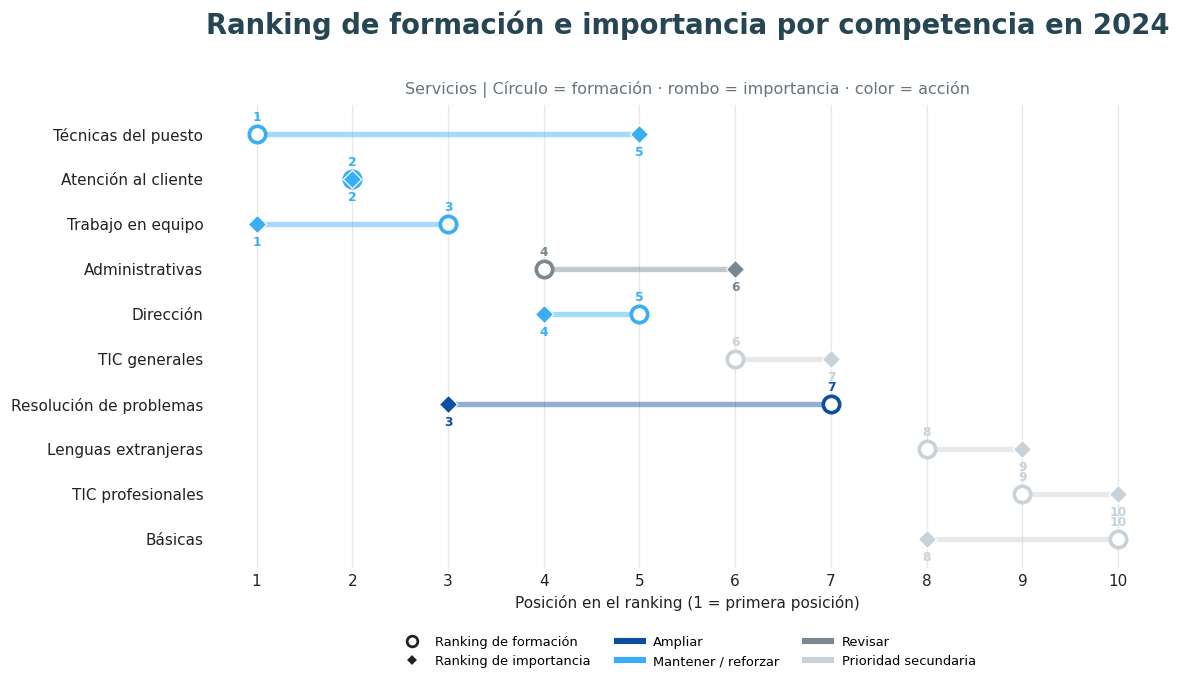

In [18]:
datos_dumbbell_2024 = alineamiento_2024.reset_index(drop=True).copy()
posiciones_dumbbell = np.arange(len(datos_dumbbell_2024))

fig, ax = plt.subplots(figsize=(10.8, 7.2))

for posicion, (_, fila) in zip(
    posiciones_dumbbell,
    datos_dumbbell_2024.iterrows(),
):
    color_accion = COLORES_ACCION[fila["accion"]]
    ranking_formacion = int(fila["rank_formacion"])
    ranking_importancia = int(fila["rank_importancia"])

    ax.plot(
        [ranking_formacion, ranking_importancia],
        [posicion, posicion],
        color=color_accion,
        linewidth=3.5,
        alpha=0.45,
        solid_capstyle="round",
        zorder=1,
    )
    ax.scatter(
        ranking_formacion,
        posicion,
        s=115,
        marker="o",
        facecolor="white",
        edgecolor=color_accion,
        linewidth=2.4,
        zorder=3,
    )
    ax.scatter(
        ranking_importancia,
        posicion,
        s=72,
        marker="D",
        color=color_accion,
        edgecolor="white",
        linewidth=0.8,
        zorder=4,
    )
    ax.annotate(
        str(ranking_formacion),
        (ranking_formacion, posicion),
        xytext=(0, 11),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color=color_accion,
    )
    ax.annotate(
        str(ranking_importancia),
        (ranking_importancia, posicion),
        xytext=(0, -12),
        textcoords="offset points",
        ha="center",
        va="center",
        fontsize=8,
        fontweight="bold",
        color=color_accion,
    )

ax.set_xlim(0.5, 10.5)
ax.set_xticks(range(1, 11))
ax.set_ylim(-0.65, len(datos_dumbbell_2024) - 0.35)
ax.set_yticks(
    posiciones_dumbbell,
    datos_dumbbell_2024["etiqueta"],
)
ax.invert_yaxis()
ax.set_xlabel("Posición en el ranking (1 = primera posición)")
ax.set_ylabel("")
ax.set_title(
    "Ranking de formación e importancia por competencia en 2024",
    loc="center",
    pad=46,
)
ax.text(
    0.5,
    1.015,
    "Servicios | Círculo = formación · rombo = importancia · color = acción",
    transform=ax.transAxes,
    ha="center",
    va="bottom",
    fontsize=10.5,
    color=GRIS,
)
ax.grid(
    axis="x",
    color=COLOR_GRID_BARRAS,
    linewidth=0.8,
    alpha=0.65,
)
ax.grid(axis="y", visible=False)

handles_dumbbell = [
    Line2D(
        [0], [0],
        marker="o",
        markerfacecolor="white",
        markeredgecolor=TINTA,
        markeredgewidth=1.8,
        linestyle="none",
        markersize=7,
        label="Ranking de formación",
    ),
    Line2D(
        [0], [0],
        marker="D",
        markerfacecolor=TINTA,
        markeredgecolor="white",
        linestyle="none",
        markersize=6,
        label="Ranking de importancia",
    ),
]
handles_dumbbell.extend(
    Line2D(
        [0], [0],
        color=COLORES_ACCION[accion_nombre],
        linewidth=4,
        label=accion_nombre,
    )
    for accion_nombre in orden_acciones_sector
)
ax.legend(
    handles=handles_dumbbell,
    frameon=False,
    ncol=3,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.12),
    fontsize=8.5,
)
plt.tight_layout(rect=[0, 0.10, 1, 1])
plt.show()


#### Riesgo de cobertura formativa

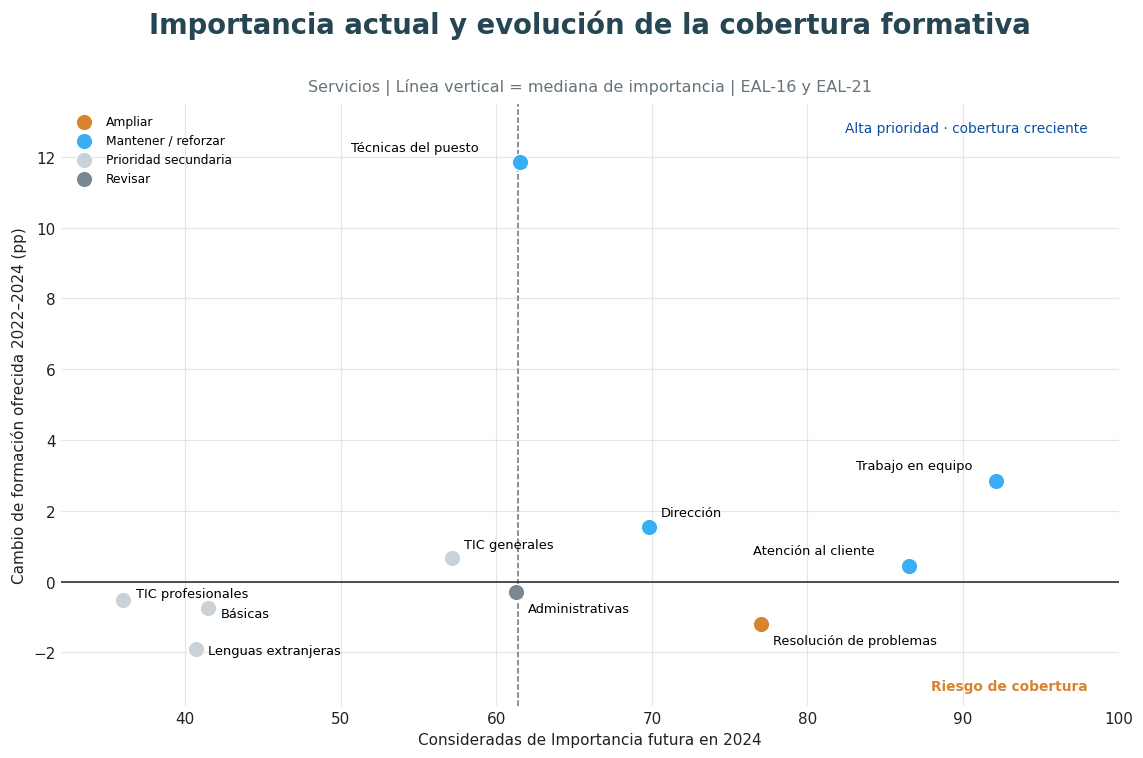

In [19]:
riesgo_sector = (
    datos_2024.merge(
        evol_formacion.query("competencia_id != 'otras'")[
            ["competencia_id", "cambio_22_24_pp"]
        ].rename(columns={"cambio_22_24_pp": "cambio_formacion_pp"}),
        on="competencia_id",
        validate="one_to_one",
    )
)
mediana_importancia_sector = riesgo_sector["importancia"].median()

# En este mapa, naranja identifica la acción Ampliar y refuerza la
# lectura del cuadrante de riesgo de cobertura.
colores_accion_riesgo = {**COLORES_ACCION, "Ampliar": NARANJA}

fig, ax = plt.subplots(figsize=(10.5, 7))
for nombre, grupo in riesgo_sector.groupby("accion"):
    ax.scatter(
        grupo["importancia"], grupo["cambio_formacion_pp"],
        s=115, color=colores_accion_riesgo[nombre], edgecolor="white",
        linewidth=0.8, label=nombre, zorder=3,
    )

desplazamientos_riesgo = {
    "Trabajo en equipo": (-92, 8),
    "Atención al cliente": (-102, 8),
    "Resolución de problemas": (8, -13),
    "Dirección": (8, 7),
    "Técnicas del puesto": (-110, 7),
    "Administrativas": (8, -13),
    "TIC generales": (8, 7),
    "Básicas": (8, -6),
    "Lenguas extranjeras": (8, -3),
    "TIC profesionales": (8, 2),
}
for _, fila in riesgo_sector.iterrows():
    dx, dy = desplazamientos_riesgo.get(fila["etiqueta"], (7, 5))
    ax.annotate(
        fila["etiqueta"],
        (fila["importancia"], fila["cambio_formacion_pp"]),
        xytext=(dx, dy), textcoords="offset points", fontsize=8.5,
    )

ax.axvline(mediana_importancia_sector, color=GRIS, linestyle="--", linewidth=1)
ax.axhline(0, color=TINTA, linewidth=1)
ax.text(98, -3.05, "Riesgo de cobertura", ha="right", color=NARANJA, fontsize=9, fontweight="bold")
ax.text(98, 12.7, "Alta prioridad · cobertura creciente", ha="right", color=AZUL, fontsize=9)
ax.set_xlim(32, 100)
ax.set_ylim(-3.5, 13.5)
ax.set_xlabel("Consideradas de Importancia futura en 2024")
ax.set_ylabel("Cambio de formación ofrecida 2022–2024 (pp)")
ax.set_title("Importancia actual y evolución de la cobertura formativa", loc="center", pad=46)
ax.text(
    0.5, 1.015,
    "Servicios | Línea vertical = mediana de importancia | EAL-16 y EAL-21",
    transform=ax.transAxes,
    ha="center", va="bottom", fontsize=10.5,
    color=GRIS,
)
ax.grid(color=COLOR_GRID_BARRAS, linewidth=0.8, alpha=0.65)
ax.legend(frameon=False, fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

### 9. Especificidad de Servicios frente al total empresarial

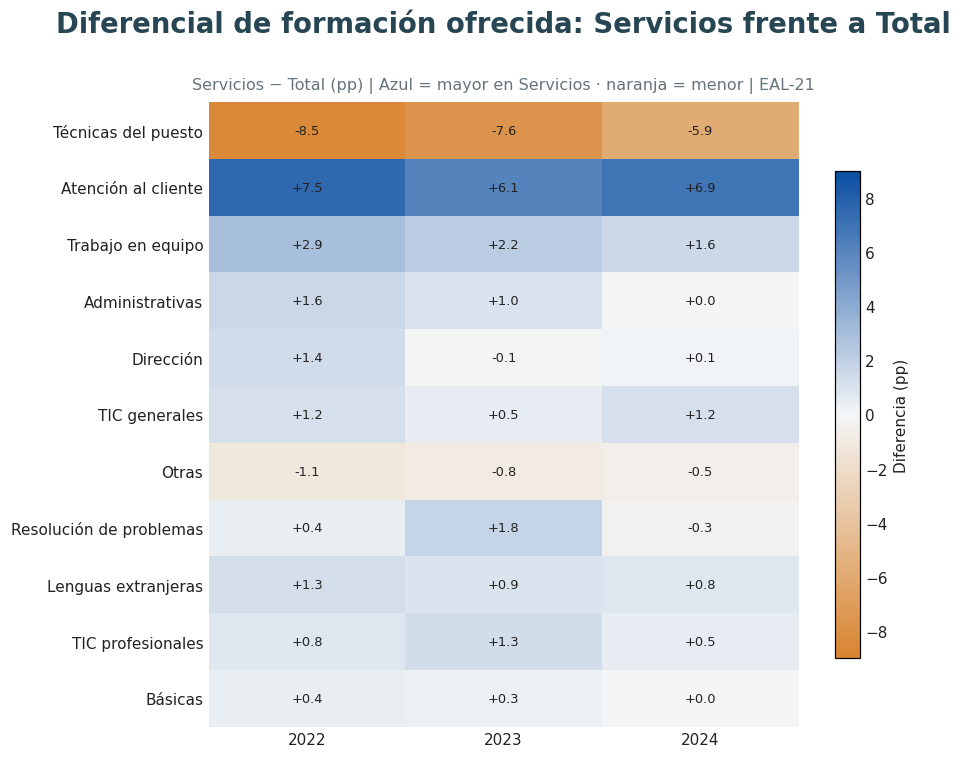

In [20]:
formacion_total = (
    datos.query(
        "tema == 'formacion_ofrecida' and hoja_origen == 'EAL-21' and "
        "desglose == 'total' and corte == 'Total'"
    )[["anio", "competencia_id", "porcentaje"]]
    .rename(columns={"porcentaje": "valor_total"})
)

diferencial_formacion = (
    formacion[["anio", "competencia_id", "valor"]]
    .merge(formacion_total, on=["anio", "competencia_id"], validate="one_to_one")
    .assign(diferencia=lambda tabla: tabla["valor"] - tabla["valor_total"])
)

orden_diferencial = (
    formacion.query("anio == 2024").sort_values("valor", ascending=False)["competencia_id"].tolist()
)
matriz_dif_formacion = (
    diferencial_formacion.pivot(index="competencia_id", columns="anio", values="diferencia")
    .loc[orden_diferencial, [2022, 2023, 2024]]
)

cmap_diferencial = LinearSegmentedColormap.from_list(
    "naranja_neutro_azul", [NARANJA, "#F4F6F7", AZUL]
)
limite_diferencial = float(np.ceil(np.abs(matriz_dif_formacion.values).max()))

fig, ax = plt.subplots(figsize=(8.8, 7.0))
imagen = ax.imshow(
    matriz_dif_formacion.values, cmap=cmap_diferencial,
    vmin=-limite_diferencial, vmax=limite_diferencial, aspect="auto",
)
for fila in range(matriz_dif_formacion.shape[0]):
    for columna in range(matriz_dif_formacion.shape[1]):
        valor = matriz_dif_formacion.iloc[fila, columna]
        valor_mostrar = 0.0 if abs(valor) < 0.05 else valor
        ax.text(columna, fila, f"{valor_mostrar:+.1f}", ha="center", va="center", fontsize=8.5, color=TINTA)

ax.set_xticks(range(3), [2022, 2023, 2024])
ax.set_yticks(range(len(orden_diferencial)), [ETIQUETAS[idx] for idx in orden_diferencial])
ax.set_title("Diferencial de formación ofrecida: Servicios frente a Total", loc="center", pad=46)
ax.text(
    0.5, 1.015,
    "Servicios − Total (pp) | Azul = mayor en Servicios · naranja = menor | EAL-21",
    transform=ax.transAxes,
    ha="center", va="bottom", fontsize=10.5,
    color=GRIS,
)
ax.tick_params(length=0)
fig.colorbar(imagen, ax=ax, label="Diferencia (pp)", shrink=0.78)
plt.tight_layout()
plt.show()

## Conclusiones detalladas

In [21]:
# Tabla final: evidencia y acción por competencia
tabla_decision = (
    datos_2024.merge(
        evol_importancia[["competencia_id", "cambio_22_24_pp"]].rename(columns={"cambio_22_24_pp": "cambio_importancia_pp"}),
        on="competencia_id",
        validate="one_to_one",
    )
    .merge(
        evol_formacion[["competencia_id", "cambio_22_24_pp"]].rename(columns={"cambio_22_24_pp": "cambio_formacion_pp"}),
        on="competencia_id",
        validate="one_to_one",
    )
)

def recomendacion(fila):
    if fila["accion"] == "Ampliar":
        return "Aumentar contenidos, plazas y aplicación al puesto"
    if fila["accion"] == "Mantener / reforzar":
        return "Mantener cobertura y medir transferencia al puesto"
    if fila["accion"] == "Revisar":
        return "Revisar intensidad y reasignar si no aporta impacto"
    return "Mantener vigilancia; no priorizar inversión adicional"

tabla_decision["recomendacion"] = tabla_decision.apply(recomendacion, axis=1)
orden_accion = ["Ampliar", "Mantener / reforzar", "Revisar", "Prioridad secundaria"]
tabla_decision["accion"] = pd.Categorical(tabla_decision["accion"], orden_accion, ordered=True)
tabla_decision = tabla_decision.sort_values(["accion", "rank_importancia"])

display(tabla_decision[[
    "accion", "competencia", "importancia", "rank_importancia",
    "cambio_importancia_pp", "formacion", "rank_formacion",
    "cambio_formacion_pp", "brecha_relativa", "recomendacion",
]].round(2))

rho_2022 = alineamiento.query("anio == 2022")["importancia"].corr(
    alineamiento.query("anio == 2022")["formacion"], method="spearman"
)
rho_2024 = alineamiento.query("anio == 2024")["importancia"].corr(
    alineamiento.query("anio == 2024")["formacion"], method="spearman"
)

def formato_p(p_valor):
    return "<0.0001" if p_valor < 0.0001 else f"{p_valor:.4f}"

def describir_cambios_significativos(indicador):
    subset = df_significacion.query(
        "indicador == @indicador and cambio_significativo"
    ).sort_values(["periodo", "p_valor"])
    if subset.empty:
        return "ningún cambio"
    return "; ".join(
        f"{fila['etiqueta']} ({fila['periodo']}, {fila['variacion_pp']:+.1f} pp, p={formato_p(fila['p_valor'])})"
        for _, fila in subset.iterrows()
    )

detalle_sig_importancia = describir_cambios_significativos("Importancia futura")
detalle_sig_formacion = describir_cambios_significativos("Formación ofrecida")

dif_2024 = (
    diferencial_formacion.query("anio == 2024")
    .set_index("competencia_id")["diferencia"]
)

def recuento_senales(indicador, periodo):
    fila = resumen_significacion.query(
        "indicador == @indicador and periodo == @periodo"
    ).iloc[0]
    return int(fila["cambios_significativos"]), int(fila["competencias_contrastadas"])

sig_imp_22_23 = recuento_senales("Importancia futura", "2022→2023")
sig_imp_23_24 = recuento_senales("Importancia futura", "2023→2024")
sig_for_22_23 = recuento_senales("Formación ofrecida", "2022→2023")
sig_for_23_24 = recuento_senales("Formación ofrecida", "2023→2024")

conclusiones = f'''
### Conclusiones para el sector Servicios

1. **El núcleo estratégico es estable.** Trabajo en equipo, Atención al cliente y Resolución de problemas ocupan los tres primeros puestos de importancia en los tres años. En 2024 alcanzan **92,1 %**, **86,5 %** y **77,0 %**. Esto respalda una política plurianual, no acciones aisladas por ejercicio.
2. **La formación técnica es la señal de crecimiento más clara.** Las competencias técnicas aumentan **+10,8 pp** en importancia y **+11,9 pp** en formación entre 2022 y 2024. La oferta ya responde a la tendencia y ocupa el primer puesto: conviene mantenerla, actualizar contenidos y medir su aplicación al puesto, no ampliarla automáticamente.
3. **Resolución de problemas es la principal oportunidad de cobertura.** En 2024 es 3.ª en importancia, pero 7.ª entre las diez competencias comparables y 8.ª en el ranking completo (**10,9 %**); además, la formación retrocede **−1,2 pp** desde 2022. Aunque su importancia también baja **−3,5 pp**, continúa en el núcleo estratégico y es la única competencia clasificada como `Ampliar` en 2024.
4. **Administrativas de oficina requiere revisión.** Su importancia cae **−5,0 pp**, mientras la formación permanece prácticamente estable (**−0,3 pp**) y ocupa el 4.º puesto de oferta. Antes de reasignar recursos debe comprobarse la demanda interna por puestos y el impacto de los cursos.
5. **La categoría Otras pierde peso, pero no es interpretable como competencia.** Su formación desciende **−5,1 pp** y no tiene equivalente en importancia futura. Debe abrirse el detalle de cursos antes de concluir que existe sobreoferta o decidir recortes.
6. **El alineamiento mejora, pero sigue siendo parcial.** La correlación de rangos de Spearman pasa de **{rho_2022:.2f}** en 2022 a **{rho_2024:.2f}** en 2024; coinciden 2 de las 3 primeras y 4 de las 5 primeras competencias. Es una mejora descriptiva moderada, no una prueba de causalidad ni de impacto.
7. **Servicios presenta una cartera específica frente al total empresarial.** En 2024 la formación en Atención al cliente está **{dif_2024['atencion_clientes']:+.1f} pp** por encima del total, mientras Técnicas del puesto está **{dif_2024['tecnicas_puesto']:+.1f} pp** respecto al total. Estas diferencias sirven como referencia sectorial, pero no indican por sí solas déficit o exceso.
8. **Los contrastes solo aportan señales exploratorias.** En importancia futura aparecen señales en **{sig_imp_22_23[0]}/{sig_imp_22_23[1]}** competencias entre 2022–2023 y **{sig_imp_23_24[0]}/{sig_imp_23_24[1]}** entre 2023–2024; en formación, en **{sig_for_22_23[0]}/{sig_for_22_23[1]}** y **{sig_for_23_24[0]}/{sig_for_23_24[1]}**, respectivamente. Las de mayor magnitud son el aumento de Técnicas del puesto en importancia (**+7,6 pp**) y formación (**+11,6 pp**) entre 2023–2024, junto con descensos de importancia en Resolución de problemas (**−6,3 pp**), Básicas (**−6,4 pp**), Lenguas extranjeras (**−5,7 pp**) y TIC generales (**−5,5 pp**). La tabla del apartado 8 conserva el detalle completo. La inferencia de EAL-21 es especialmente provisional porque usa una muestra formadora aproximada; además, ningún contraste incorpora el diseño muestral ni corrige la multiplicidad.

### Implicaciones para la política formativa

- **Prioridad 1 — ampliar Resolución de problemas:** crear un itinerario aplicado a incidencias, calidad, toma de decisiones y mejora continua; segmentarlo por función y medir uso real en el puesto.
- **Prioridad 2 — consolidar Técnicas del puesto:** mantener cobertura, actualizar contenidos y evitar crecer por inercia; vincularla a tiempo hasta autonomía, errores, productividad y seguridad.
- **Prioridad 3 — proteger el núcleo transversal:** conservar Trabajo en equipo y Atención al cliente, adaptando profundidad y metodología a los colectivos con mayor exposición.
- **Optimizar cartera:** revisar Administrativas y abrir la categoría Otras curso a curso antes de reasignar presupuesto.
- **Cerrar la medición de impacto:** combinar la referencia EAL con participación, finalización, aprendizaje, transferencia y resultados operativos internos. Sin esa capa, el análisis orienta prioridades, pero no demuestra retorno.

### Criterio de decisión

La recomendación no es copiar la media de Servicios, sino usarla como **benchmark externo**. La decisión final debe cruzar prioridad sectorial, brecha interna por puesto, coste, participación, transferencia y evolución de indicadores operativos.
'''

display(Markdown(conclusiones))

,accion,competencia,importancia,rank_importancia,cambio_importancia_pp,formacion,rank_formacion,cambio_formacion_pp,brecha_relativa,recomendacion
5,Ampliar,Resolución de problemas,77.00,3,-3.51,10.89,7,-1.20,0.40,"Aumentar contenidos, plazas y aplicación al puesto"
9,Mantener / reforzar,Trabajo en equipo,92.13,1,0.99,30.08,3,2.85,0.20,Mantener cobertura y medir transferencia al puesto
1,Mantener / reforzar,Atención al público / trato a clientes,86.51,2,0.22,31.46,2,0.45,0.00,Mantener cobertura y medir transferencia al puesto
3,Mantener / reforzar,Dirección,69.81,4,-0.47,16.44,5,1.54,0.10,Mantener cobertura y medir transferencia al puesto
6,Mantener / reforzar,Competencias técnicas del puesto de trabajo,61.49,5,10.83,44.99,1,11.86,-0.40,Mantener cobertura y medir transferencia al puesto
0,Revisar,Administrativas de oficina,61.24,6,-5.05,16.99,4,-0.29,-0.20,Revisar intensidad y reasignar si no aporta impacto
7,Prioridad secundaria,Generales de tecnologías de la información,57.14,7,-4.24,13.84,6,0.65,-0.10,Mantener vigilancia; no priorizar inversión adicional
2,Prioridad secundaria,Básicas de cálculo y/o comunicación oral o escrita,41.48,8,-3.37,1.27,10,-0.73,0.20,Mantener vigilancia; no priorizar inversión adicional
4,Prioridad secundaria,Lenguas extranjeras,40.66,9,-4.22,8.26,8,-1.90,-0.10,Mantener vigilancia; no priorizar inversión adicional
8,Prioridad secundaria,Profesionales de tecnologías de la información,36.02,10,-1.00,5.81,9,-0.51,-0.10,Mantener vigilancia; no priorizar inversión adicional



### Conclusiones para el sector Servicios

1. **El núcleo estratégico es estable.** Trabajo en equipo, Atención al cliente y Resolución de problemas ocupan los tres primeros puestos de importancia en los tres años. En 2024 alcanzan **92,1 %**, **86,5 %** y **77,0 %**. Esto respalda una política plurianual, no acciones aisladas por ejercicio.
2. **La formación técnica es la señal de crecimiento más clara.** Las competencias técnicas aumentan **+10,8 pp** en importancia y **+11,9 pp** en formación entre 2022 y 2024. La oferta ya responde a la tendencia y ocupa el primer puesto: conviene mantenerla, actualizar contenidos y medir su aplicación al puesto, no ampliarla automáticamente.
3. **Resolución de problemas es la principal oportunidad de cobertura.** En 2024 es 3.ª en importancia, pero 7.ª entre las diez competencias comparables y 8.ª en el ranking completo (**10,9 %**); además, la formación retrocede **−1,2 pp** desde 2022. Aunque su importancia también baja **−3,5 pp**, continúa en el núcleo estratégico y es la única competencia clasificada como `Ampliar` en 2024.
4. **Administrativas de oficina requiere revisión.** Su importancia cae **−5,0 pp**, mientras la formación permanece prácticamente estable (**−0,3 pp**) y ocupa el 4.º puesto de oferta. Antes de reasignar recursos debe comprobarse la demanda interna por puestos y el impacto de los cursos.
5. **La categoría Otras pierde peso, pero no es interpretable como competencia.** Su formación desciende **−5,1 pp** y no tiene equivalente en importancia futura. Debe abrirse el detalle de cursos antes de concluir que existe sobreoferta o decidir recortes.
6. **El alineamiento mejora, pero sigue siendo parcial.** La correlación de rangos de Spearman pasa de **0.64** en 2022 a **0.71** en 2024; coinciden 2 de las 3 primeras y 4 de las 5 primeras competencias. Es una mejora descriptiva moderada, no una prueba de causalidad ni de impacto.
7. **Servicios presenta una cartera específica frente al total empresarial.** En 2024 la formación en Atención al cliente está **+6.9 pp** por encima del total, mientras Técnicas del puesto está **-5.9 pp** respecto al total. Estas diferencias sirven como referencia sectorial, pero no indican por sí solas déficit o exceso.
8. **Los contrastes solo aportan señales exploratorias.** En importancia futura aparecen señales en **4/10** competencias entre 2022–2023 y **7/10** entre 2023–2024; en formación, en **4/11** y **8/11**, respectivamente. Las de mayor magnitud son el aumento de Técnicas del puesto en importancia (**+7,6 pp**) y formación (**+11,6 pp**) entre 2023–2024, junto con descensos de importancia en Resolución de problemas (**−6,3 pp**), Básicas (**−6,4 pp**), Lenguas extranjeras (**−5,7 pp**) y TIC generales (**−5,5 pp**). La tabla del apartado 8 conserva el detalle completo. La inferencia de EAL-21 es especialmente provisional porque usa una muestra formadora aproximada; además, ningún contraste incorpora el diseño muestral ni corrige la multiplicidad.

### Implicaciones para la política formativa

- **Prioridad 1 — ampliar Resolución de problemas:** crear un itinerario aplicado a incidencias, calidad, toma de decisiones y mejora continua; segmentarlo por función y medir uso real en el puesto.
- **Prioridad 2 — consolidar Técnicas del puesto:** mantener cobertura, actualizar contenidos y evitar crecer por inercia; vincularla a tiempo hasta autonomía, errores, productividad y seguridad.
- **Prioridad 3 — proteger el núcleo transversal:** conservar Trabajo en equipo y Atención al cliente, adaptando profundidad y metodología a los colectivos con mayor exposición.
- **Optimizar cartera:** revisar Administrativas y abrir la categoría Otras curso a curso antes de reasignar presupuesto.
- **Cerrar la medición de impacto:** combinar la referencia EAL con participación, finalización, aprendizaje, transferencia y resultados operativos internos. Sin esa capa, el análisis orienta prioridades, pero no demuestra retorno.

### Criterio de decisión

La recomendación no es copiar la media de Servicios, sino usarla como **benchmark externo**. La decisión final debe cruzar prioridad sectorial, brecha interna por puesto, coste, participación, transferencia y evolución de indicadores operativos.


## Limitaciones y trazabilidad

- **Fuente principal:** `Data/Encuesta_EAL/processed/Tablas_EAL_Competencies_2022-2024.csv`.
- EAL-16 usa todas las empresas de la categoría; EAL-21 solo empresas formadoras. Sus porcentajes no comparten denominador y no se restan directamente.
- **Servicios es un agregado amplio y heterogéneo**, utilizado como aproximación porque no existe una serie comparable específica de Transporte y almacenamiento. Los resultados no deben presentarse como si describieran exclusivamente ese subsector.
- EAL-21 admite respuesta múltiple y sus porcentajes no deben sumar 100.
- Solo se comparan directamente las diez competencias comunes; `Otras` se analiza por separado.
- Tres observaciones anuales permiten describir evolución reciente, pero no estimar una tendencia temporal estable ni atribuir causalidad.
- Los tests Z utilizan las muestras de Servicios del Informe Metodológico Estandarizado: 6.266 empresas (2022), 6.107 (2023) y 5.963 (2024), siguiendo el procedimiento del notebook de Barreras.
- EAL-C1 aporta el marco poblacional de empresas, no la muestra. Combinándolo con el porcentaje de empresas formadoras de EAL-17 (2022) y EAL-18a (2023–2024) se estiman 167.289, 176.094 y 184.018 empresas formadoras de Servicios.
- Para EAL-21 se aplica la proporción estimada de formadoras a la muestra sectorial, obteniendo muestras aproximadas de 4.366, 4.314 y 4.302 empresas.
- Los valores p son exploratorios: suponen muestras aleatorias simples independientes, aproximan los recuentos a partir de porcentajes publicados y no incorporan ponderaciones, estratos, conglomerados ni otros efectos del diseño muestral.
- La muestra formadora calculada no sustituye al recuento muestral observado del subgrupo, que no se publica en estas tablas.
- Se realizan múltiples contrastes sin corrección; `p < 0,05` identifica señales exploratorias, no evidencia confirmatoria. La magnitud en puntos porcentuales y la relevancia operativa deben pesar más que el valor p aislado.
- La comparación `Servicios − Total` solo contextualiza la especialización de la oferta; no demuestra déficit, sobreoferta ni mejor desempeño.
- La EAL orienta prioridades. El impacto sobre productividad, calidad, promoción, seguridad o retención debe medirse con datos internos y, cuando sea posible, con diseños pre/post o grupos comparables.